# Energy model validation and coefficient profiles

Load an `energy_model_training` run, restore its exact held-out graphs, and inspect the fixed-accommodation sweep. This notebook **does not fit or select models**. Ordinary and spherical validation remain distinct in the score tables. Spherical organoids and ordinary no-detected-crypt organoids are combined only in their requested reporting panel; total MSE refers to ordinary validation alone. Unqualified boundary cells remain in total MSE but have no separate regional panel.

Plot mean-curvature MSE, center-identity preferred residual curvatures \(a_A\), and allowed source-to-recipient amplitudes \(\beta_{AB}\) against accommodation \(\gamma\). Thin lines show individual folds; the thicker line is their mean. At fixed gamma, changing other fitted coefficients is precisely the compensation being investigated. Center coefficients are relative to the saved global baseline, not absolute measured native cell shapes or uniquely identified material parameters.

All annotation labels, preprocessing, baselines and train/validation memberships come from this run. No old experiment tables or reference model runs are required. The spherical cohort is a separate validation dataset and is not used for tuning accommodation or shrinkage. Review the settings below after training, then execute.

The plain depth-1 GIN reference shares the exact exclusive fates, residual targets, baseline and ordinary outer split. It has no global inputs or FiLM. Its epoch count uses only an inner training holdout, followed by a full-training refit. Its horizontal reference line is repeated across the accommodation grid only for display; it is one trained model per fold. The energy model has longer effective reach through accommodation.

This evaluation also compares whole-organoid and source-neighborhood lineage composition between spherical-like and non-spherical cohorts and quantifies parameter variation/sign agreement across folds at every gamma. It does not train models or tune them on spherical organoids.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display, Markdown
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'src/models/gnn.py').is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.artifacts.bundle import load_bundle, graph_membership
from src.artifacts.runs import AnalysisRun
from src.artifacts.paths import resolve_training_run
from src.training.coupled_fit import graph_samples
from src.inference.predict import predict_targets
from src.models.gnn import GINCurvature
from src.data.neighborhood_counts import fate_identities, exact_hop_counts
from matplotlib.patches import Rectangle

## Settings
Choose a completed run. If there is exactly one energy-model run, `TRAINING_RUN=None` resolves it; otherwise specify its folder explicitly. All folds and gamma values in that run are analyzed. There is no independent data-filter setting here that could accidentally change the evaluation cohort.

In [2]:
# Saved models and inference
TRAINING_RUN = 'training_results/energy_model_training/all_to_all_linear_fraction_hop1_matched_20261002_133445'  # Folder under training_results/energy_model_training; None requires exactly one run.
OUTPUT_TAG = 'accommodation_profiles'  # Evaluation subfolder inside the selected training run.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # Device for restoring predicted mean curvature.

# Plot appearance
GAMMA_LINTHRESH = .1  # Linear interval around zero on the otherwise logarithmic accommodation axis.
THIN_LINE_WIDTH = .8  # Individual fold curves.
MEAN_LINE_WIDTH = 2.5  # Mean across folds.
SHOW_MSE_SEM = True  # Single fold: organoid SEM; multiple folds: fold-mean SEM.
FOLD_ALPHA = .3  # Transparency of individual fold curves and points.

# Composition and stability summaries
SIGN_TOLERANCE = .001  # Near-zero band in residual H units; descriptive, not a significance threshold.
LINEAGE_GROUPS = {
    'EXO': ['Agr2', 'Lysozyme'],  # Exocrine marker group.
    'ENDO': ['Chroma', 'Serotonin'],  # Endocrine marker group.
    'LGR5': ['LGR5'],  # Stem-marker identity.
    'KI67': ['KI67'],  # Exclusive proliferative identity.
    'AldoB': ['AldoB'],  # Absorptive-marker identity.
    'Unassigned': ['Unassigned'],  # Observed all-zero fate identity.
}

# Optional matched model comparison
STABILITY_REFERENCE_RUN = 'training_results/energy_model_training/all_to_all_presence_hop1_matched_20261002_130854'  # None disables comparison; inputs/baselines must match exactly.
COMPOSITION_CENTERS = ['Agr2', 'Chroma', 'Lysozyme', 'Serotonin']  # Which identities to display in the neighborhood composition figure; does not restrict the model.

# Linear-versus-presence parameter diagnostics
COEFFICIENT_REFERENCE = 'Unassigned'  # Analysis reference for pure-neighborhood contrasts; does not constrain or refit coefficients.
VARIANCE_FLOOR = 1e-18  # Denominators below this variance are reported as undefined ratios.


## Restore and verify the run
Require completion, one checkpoint for every fold/gamma combination, exact fixed strength, restricted direct interactions, and identical saved validation memberships. Baselines are restored with the inputs and do not refit. Labels from excluded boundary cells are retained for accounting but not plotted as a region.

In [3]:
run=AnalysisRun(resolve_training_run(PROJECT_ROOT,'energy_model_training',TRAINING_RUN))
if not (run.directory/'complete.json').exists():raise ValueError('Training run is incomplete.')
settings=run.settings;membership=json.loads((run.directory/'splits.json').read_text())
cohort=load_bundle(run.directory/'cohort');marker_names=cohort['all_marker_names'];identity_names=list(marker_names)+['Unassigned']
regions=pd.read_csv(run.directory/'regions.csv.gz')
energy_records=run.records[run.records.family=='energy'].copy()
gin_records=run.records[run.records.family=='gin'].copy()
if settings.get('gin_enabled',False) and (set(gin_records.fold)!={s['fold'] for s in membership} or gin_records.fold.duplicated().any()):raise ValueError('Missing or duplicate GIN reference.')
expected={(s['fold'],float(g)) for s in membership for g in settings['gamma_grid']}
if set(zip(energy_records.fold,energy_records.gamma))!=expected or energy_records.duplicated(['fold','gamma']).any():raise ValueError('Incomplete or duplicated gamma grid.')
OUTPUT_DIR=run.directory/'analysis'/OUTPUT_TAG;OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
(OUTPUT_DIR/'predictions').mkdir(exist_ok=True)
(OUTPUT_DIR/'settings.json').write_text(json.dumps(dict(training_run=str(run.directory),device=DEVICE,gamma_linthresh=GAMMA_LINTHRESH,show_mse_sem=SHOW_MSE_SEM,sign_tolerance=SIGN_TOLERANCE,lineage_groups=LINEAGE_GROUPS,fold_alpha=FOLD_ALPHA,stability_reference_run=STABILITY_REFERENCE_RUN,composition_centers=COMPOSITION_CENTERS,coefficient_reference=COEFFICIENT_REFERENCE,variance_floor=VARIANCE_FLOOR),indent=2))
print('Run:',run.directory,'| folds:',len(membership),'| gamma:',settings['gamma_grid'])
region_by_id={str(oid):group.sort_values('node') for oid,group in regions.groupby('organoid_str',sort=False)}


Run: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/energy_model_training/all_to_all_linear_fraction_hop1_matched_20261002_133445 | folds: 5 | gamma: [0.0, 0.1, 0.2, 0.4, 0.8, 1.6, 3.2, 6.4, 12.8, 25.6]


/tmp/ipykernel_2249532/3398461975.py:5: DtypeWarning: Columns (5,7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  regions=pd.read_csv(run.directory/'regions.csv.gz')


## Spherical-like versus non-spherical lineage composition
Use each original eligible organoid once, pooling ordinary training and validation membership without duplicating folds. Plot individual exclusive identities and explicitly defined lineage groups; Unassigned remains an identity. Error bars show SEM across organoids with equal organoid weights. These are unmatched descriptive cohort comparisons: N and timepoint distributions can differ.

### One-hop neighborhoods around source cells
For each source identity, exclude the center, count each adjacent cell once, and calculate neighbor identity fractions. Average over source centers within each organoid, then equally over organoids. Panels exclude organoids without a usable source center; legend `n` is the number of represented organoids. Isolated source centers are excluded and counted in the exported support table. The same exact-hop definition is used by the model.

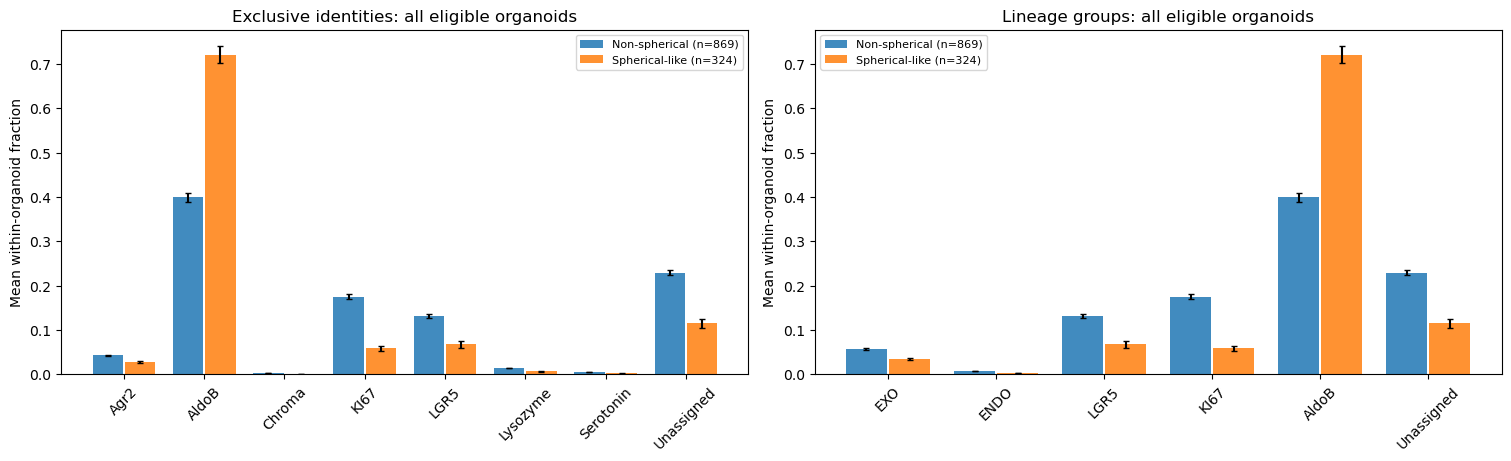

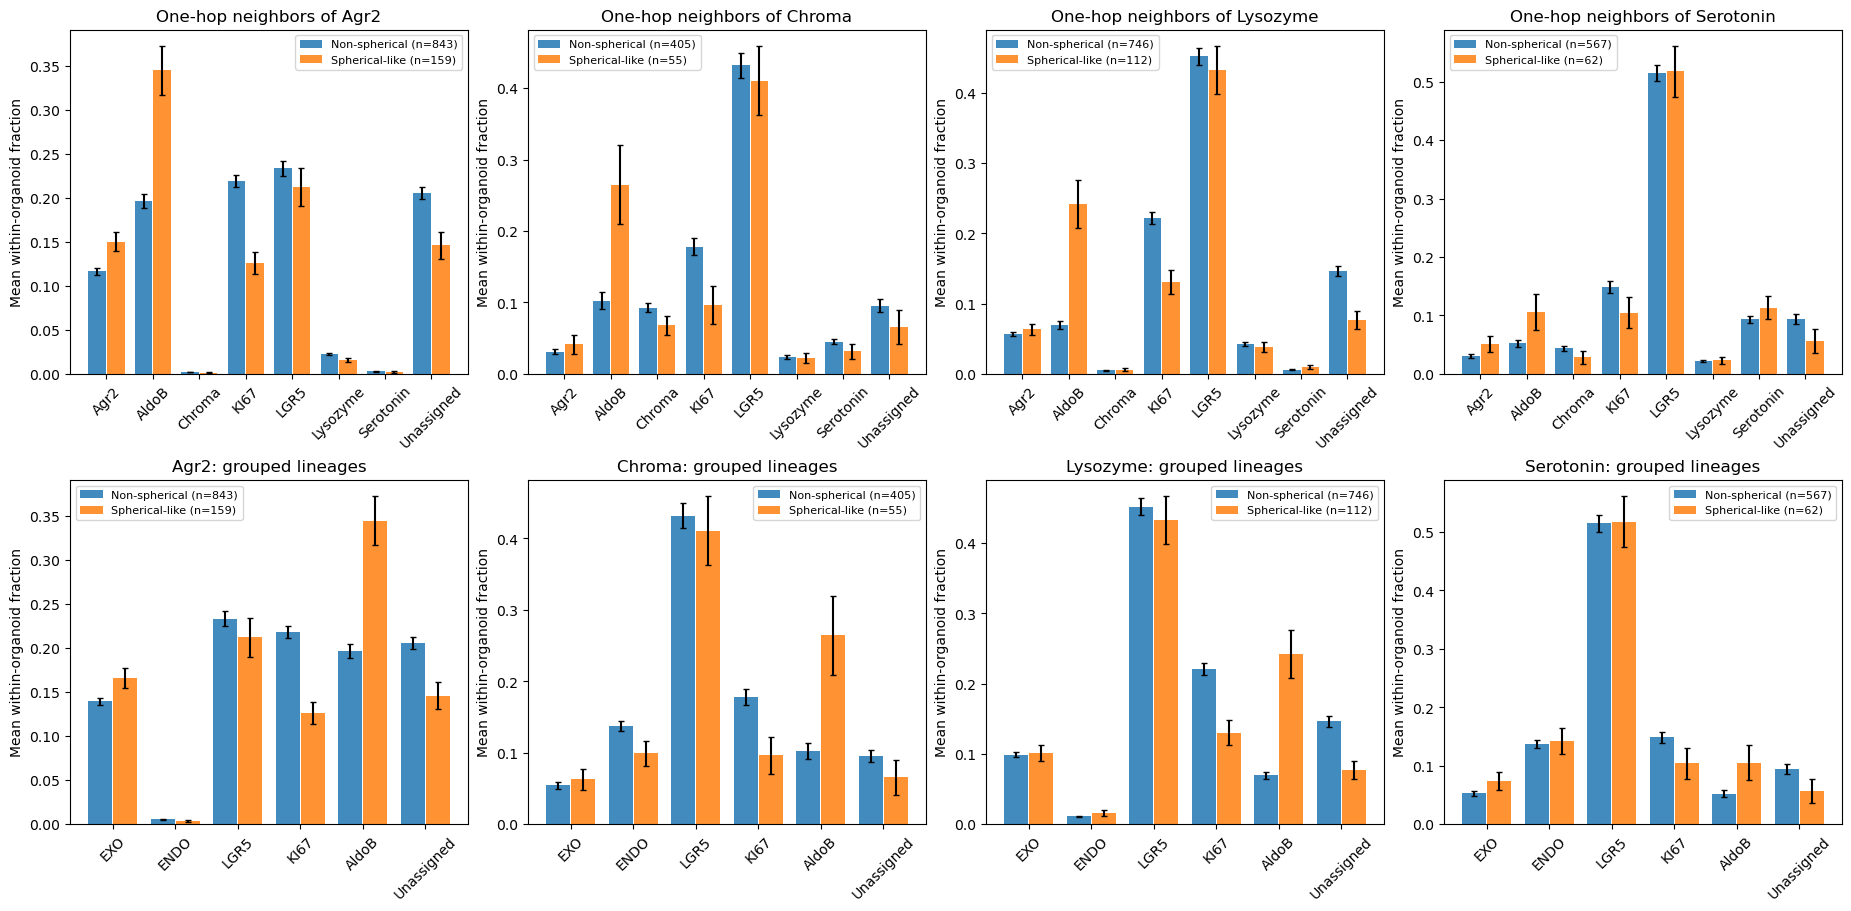

In [4]:
# Each original organoid contributes once, independent of the number of folds.
cohort_table=pd.read_csv(run.directory/'cohort.csv').set_index('organoid_str')
composition_rows=[];neighborhood_rows=[];source_support_rows=[];raw_context={}
for oid,graph in cohort['raw_graphs'].items():
    meta=cohort_table.loc[oid];identities=fate_identities(graph.x)
    counts=exact_hop_counts(graph.x,graph.edge_index,1)[:,0,:]
    raw_context[oid]=(identities,counts)
    proportions=np.bincount(identities,minlength=len(identity_names))/len(identities)
    for name,value in zip(identity_names,proportions):
        composition_rows.append(dict(organoid_str=oid,cohort=meta.cohort,timepoint=meta.timepoint,N=meta.N,identity=name,fraction=value))
    degree=counts.sum(axis=1)
    for source in settings['source_markers']:
        source_mask=identities==identity_names.index(source);usable=source_mask&(degree>0)
        source_support_rows.append(dict(organoid_str=oid,cohort=meta.cohort,source=source,source_cells=int(source_mask.sum()),usable_centers=int(usable.sum()),isolated_centers=int((source_mask&(degree==0)).sum())))
        if not usable.any():continue
        fraction=(counts[usable]/degree[usable,None]).mean(axis=0)
        for name,value in zip(identity_names,fraction):
            neighborhood_rows.append(dict(organoid_str=oid,cohort=meta.cohort,timepoint=meta.timepoint,N=meta.N,source=source,identity=name,fraction=value))
composition=pd.DataFrame(composition_rows)
neighborhood_composition=pd.DataFrame(neighborhood_rows,columns=['organoid_str','cohort','timepoint','N','source','identity','fraction'])
source_support=pd.DataFrame(source_support_rows)
lineage_lookup={marker:lineage for lineage,markers in LINEAGE_GROUPS.items() for marker in markers}
if len(lineage_lookup)!=sum(map(len,LINEAGE_GROUPS.values())) or set(lineage_lookup)!=set(identity_names):raise ValueError('Lineage groups must partition the exclusive identities exactly once.')
def grouped_composition(table):
    keys=[c for c in ['organoid_str','cohort','timepoint','N','source'] if c in table]
    return table.assign(identity=table.identity.map(lineage_lookup)).groupby(keys+['identity'],as_index=False).fraction.sum()
composition_lineages=grouped_composition(composition)
neighborhood_lineages=grouped_composition(neighborhood_composition)
for name,table in [('cohort_composition',composition),('cohort_lineage_composition',composition_lineages),('source_neighborhood_composition',neighborhood_composition),('source_neighborhood_lineage_composition',neighborhood_lineages),('source_neighborhood_support',source_support)]:
    table.to_csv(OUTPUT_DIR/f'{name}.csv',index=False)
    if 'fraction' in table and len(table):
        keys=[c for c in ['organoid_str','source'] if c in table]
        if not np.allclose(table.groupby(keys).fraction.sum(),1):raise ValueError('Composition fractions must sum to one.')

def plot_composition(ax,table,names,title):
    for offset,(role,label,color) in zip([-.2,.2],[('ordinary','Non-spherical','tab:blue'),('spherical','Spherical-like','tab:orange')]):
        subset=table[table.cohort==role]
        summary=subset.groupby('identity').fraction.agg(['mean','sem']).reindex(names)
        n=subset.organoid_str.nunique()
        if n:
            ax.bar(np.arange(len(names))+offset,summary['mean'],width=.38,color=color,alpha=.85,yerr=summary['sem'].fillna(0),capsize=2,label=f'{label} (n={n})')
    ax.set(xticks=np.arange(len(names)),xticklabels=names,ylabel='Mean within-organoid fraction',title=title)
    ax.tick_params(axis='x',rotation=45);ax.legend(fontsize=8);ax.set_ylim(bottom=0)
fig,axes=plt.subplots(1,2,figsize=(15,4.5),layout='constrained')
plot_composition(axes[0],composition,identity_names,'Exclusive identities: all eligible organoids')
plot_composition(axes[1],composition_lineages,list(LINEAGE_GROUPS),'Lineage groups: all eligible organoids')
fig.savefig(OUTPUT_DIR/'cohort_composition.png',dpi=160);plt.show()
fig,axes=plt.subplots(2,len(COMPOSITION_CENTERS),figsize=(4.6*len(COMPOSITION_CENTERS),9),squeeze=False,layout='constrained')
for j,source in enumerate(COMPOSITION_CENTERS):
    plot_composition(axes[0,j],neighborhood_composition[neighborhood_composition.source==source],identity_names,f'One-hop neighbors of {source}')
    plot_composition(axes[1,j],neighborhood_lineages[neighborhood_lineages.source==source],list(LINEAGE_GROUPS),f'{source}: grouped lineages')
fig.savefig(OUTPUT_DIR/'source_neighborhood_composition.png',dpi=160);plt.show()
# Presence and absence both matter for identifying a pair amplitude. Count training organoids, not folds pooled as observations.
support_rows=[]
for split in membership:
    for recipient in settings['recipient_markers']:
        a=identity_names.index(recipient)
        for source in settings['source_markers']:
            b=identity_names.index(source);positive=negative=source_free=0
            for oid in split['train']:
                identities,counts=raw_context[oid];center=identities==a
                positive+=int(np.any(center&(counts[:,b]>0)))
                negative+=int(np.any(center&(counts[:,b]==0)))
                source_free+=int(np.any(center&(counts[:,settings['source_indices']].sum(axis=1)==0)))
            support_rows.append(dict(fold=split['fold'],recipient=recipient,source=source,present_organoids=positive,absent_organoids=negative,source_free_organoids=source_free))
training_support=pd.DataFrame(support_rows)
training_support.to_csv(OUTPUT_DIR/'training_pair_presence_absence_support.csv',index=False)


## Predict held-out organoids and read coefficients
MSE is calculated within each organoid and then averaged across organoids. Baseline subtraction cancels in prediction error; full curvature predictions and physical targets are reconstructed and saved as well. The combined spherical/no-crypt category contains each organoid once per model. Other quality exclusions are never labeled spherical. Support tables flag allowed pairs with limited training observations.

In [5]:
score_rows=[];center_rows=[];pair_rows=[]
for split in membership:
    fold=split['fold'];data=run.fold_inputs(fold)
    if [str(g.organoid_str) for g in data['groups']['spherical']]!=split['spherical_validation']:raise ValueError('Spherical membership mismatch.')
    evaluation={role:graph_samples(group,2) for role,group in data['groups'].items() if role!='train' and group}
    for record in energy_records[energy_records.fold==fold].sort_values('gamma').itertuples():
        model=load_bundle(run.directory/record.bundle)['model'];gamma=float(record.gamma)
        if model.fixed_strength!=gamma or model.radius!=1 or model.activation!=settings['activation'] or model.center_response or model.size_dependent:
            raise ValueError('Checkpoint does not match the selected fixed-strength interaction experiment.')
        if model.source_indices!=settings['source_indices'] or model.recipient_indices!=settings['recipient_indices']:raise ValueError('Wrong source/recipient panel.')
        coefficients=model.coefficients([1])
        for a,A in enumerate(identity_names):center_rows.append(dict(fold=fold,gamma=gamma,identity=A,value=float(coefficients['center'][0,a])))
        for a in settings['recipient_indices']:
            for b in settings['source_indices']:pair_rows.append(dict(fold=fold,gamma=gamma,recipient=identity_names[a],source=identity_names[b],value=float(coefficients['amplitude'][0,a,b]),support=int(model.pair_support[a,b])))
        for role,samples in evaluation.items():
            predictions=model.predict_samples(samples,device=DEVICE,rtol=settings['solver_rtol'])
            actual=[];predicted=[];offsets=[0];ids=[]
            for sample,prediction in zip(samples,predictions):
                oid=sample['organoid_str'];labels=region_by_id[oid]
                if len(labels)!=len(prediction) or not np.array_equal(labels.node.to_numpy(),np.arange(len(prediction))):raise ValueError('Region/node mismatch.')
                error=(prediction-sample['y'])**2;baseline_error=sample['y']**2
                total_label='total' if role=='val' else 'spherical_validation_only'
                for label in [total_label,*pd.unique(labels.region)]:
                    if label in ['excluded_boundary','annotation_unavailable']:continue
                    take=np.ones(len(error),bool) if label==total_label else labels.region.to_numpy()==label
                    score_rows.append(dict(model='energy',fold=fold,gamma=gamma,cohort=role,organoid_str=oid,region=label,cells=int(take.sum()),mse=float(error[take].mean()),baseline_mse=float(baseline_error[take].mean())))
                baseline=np.asarray(data['baseline_offsets'][oid]).reshape(-1)
                actual.append(sample['y']+baseline);predicted.append(prediction+baseline);offsets.append(offsets[-1]+len(prediction));ids.append(oid)
            np.savez_compressed(OUTPUT_DIR/'predictions'/f'{record.key}_{role}.npz',truth=np.concatenate(actual),prediction=np.concatenate(predicted),offsets=np.array(offsets),organoid_ids=np.array(ids))
    for record in gin_records[gin_records.fold==fold].itertuples():
        payload=load_bundle(run.directory/record.bundle);model=payload['model']
        if type(model) is not GINCurvature or model.global_dim!=0 or model.num_layers!=settings['gin_depth']:raise ValueError('Unexpected GIN architecture.')
        if payload['metrics']['fit_organoids']!=split['train']:raise ValueError('GIN training membership differs.')
        for role in evaluation:
            group=data['groups'][role]
            if any('global_feat' in g for g in group):raise ValueError('Global features present in GIN inputs.')
            truth,pred,_=predict_targets(group,model,device=DEVICE,batch_size=settings['gin_batch_size'])
            truth=np.asarray(truth).reshape(-1);pred=np.asarray(pred).reshape(-1);offsets=[0];ids=[];full_truth=[];full_pred=[]
            for g in group:
                oid=str(g.organoid_str);start=offsets[-1];stop=start+len(g.x)
                residual=truth[start:stop];prediction=pred[start:stop]
                labels=region_by_id[oid]
                if len(labels)!=len(prediction):raise ValueError('GIN annotation length mismatch.')
                error=(prediction-residual)**2;baseline_error=residual**2
                total_label='total' if role=='val' else 'spherical_validation_only'
                for label in [total_label,*pd.unique(labels.region)]:
                    if label in ['excluded_boundary','annotation_unavailable']:continue
                    take=np.ones(len(error),bool) if label==total_label else labels.region.to_numpy()==label
                    score_rows.append(dict(model='gin',fold=fold,gamma=np.nan,cohort=role,organoid_str=oid,region=label,cells=int(take.sum()),mse=float(error[take].mean()),baseline_mse=float(baseline_error[take].mean())))
                baseline=np.asarray(data['baseline_offsets'][oid]).reshape(-1)
                full_truth.append(residual+baseline);full_pred.append(prediction+baseline);offsets.append(stop);ids.append(oid)
            np.savez_compressed(OUTPUT_DIR/'predictions'/f'{record.key}_{role}.npz',truth=np.concatenate(full_truth),prediction=np.concatenate(full_pred),offsets=np.array(offsets),organoid_ids=np.array(ids))
    print('Evaluated fold',fold)
scores=pd.DataFrame(score_rows);centers=pd.DataFrame(center_rows);pairs=pd.DataFrame(pair_rows)
for name,frame in [('validation_mse',scores),('center_preferences',centers),('interaction_amplitudes',pairs)]:frame.to_csv(OUTPUT_DIR/f'{name}.csv',index=False)
saved=pd.read_csv(run.directory/'validation_mse.csv').set_index(['fold','gamma','organoid_str']).mse
restored=scores[(scores.model=='energy')&scores.region.isin(['total','spherical_validation_only'])].set_index(['fold','gamma','organoid_str']).mse
if set(saved.index)!=set(restored.index) or not np.allclose(saved.sort_index(),restored.sort_index(),rtol=1e-8,atol=1e-11):raise ValueError('Restored scores differ from training notebook.')
support=pd.read_csv(run.directory/'pair_support.csv')
if (support.source_present_organoids<settings['min_pair_organoids']).any():
    display(support[support.source_present_organoids<settings['min_pair_organoids']])
if len(gin_records):
    saved_gin=pd.read_csv(run.directory/'gin_validation_mse.csv').set_index(['fold','organoid_str']).mse.sort_index()
    restored_gin=scores[(scores.model=='gin')&scores.region.isin(['total','spherical_validation_only'])].set_index(['fold','organoid_str']).mse.sort_index()
    if set(saved_gin.index)!=set(restored_gin.index) or not np.allclose(saved_gin,restored_gin,rtol=1e-7,atol=1e-10):raise ValueError('Restored GIN scores differ.')


/home/fmoller/Projects/LearningOrganoids/GraphNN/src/models/energy_ops.py:121: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  self.laplacian = torch.sparse_csr_tensor(self.crow,self.col,self.lap_values,size=lap.shape,device=self.device)


Evaluated fold 0


Evaluated fold 1


Evaluated fold 2


Evaluated fold 3


Evaluated fold 4


## MSE against accommodation
The six panels report ordinary total MSE and the five requested regional groups. Spherical organoids appear only in the combined spherical/no-detected-crypt panel, not in ordinary total MSE. A separate panel below keeps their standalone MSE visible. Gray lines are the fitted baseline. With multiple folds, repeated spherical organoids do not count as independent new observations in an organoid SEM; the shaded band instead summarizes fold means.
If a GIN was trained in the selected run, its reference is green; the energy-only run has none. Both the GIN and baseline are independent of the swept accommodation value.

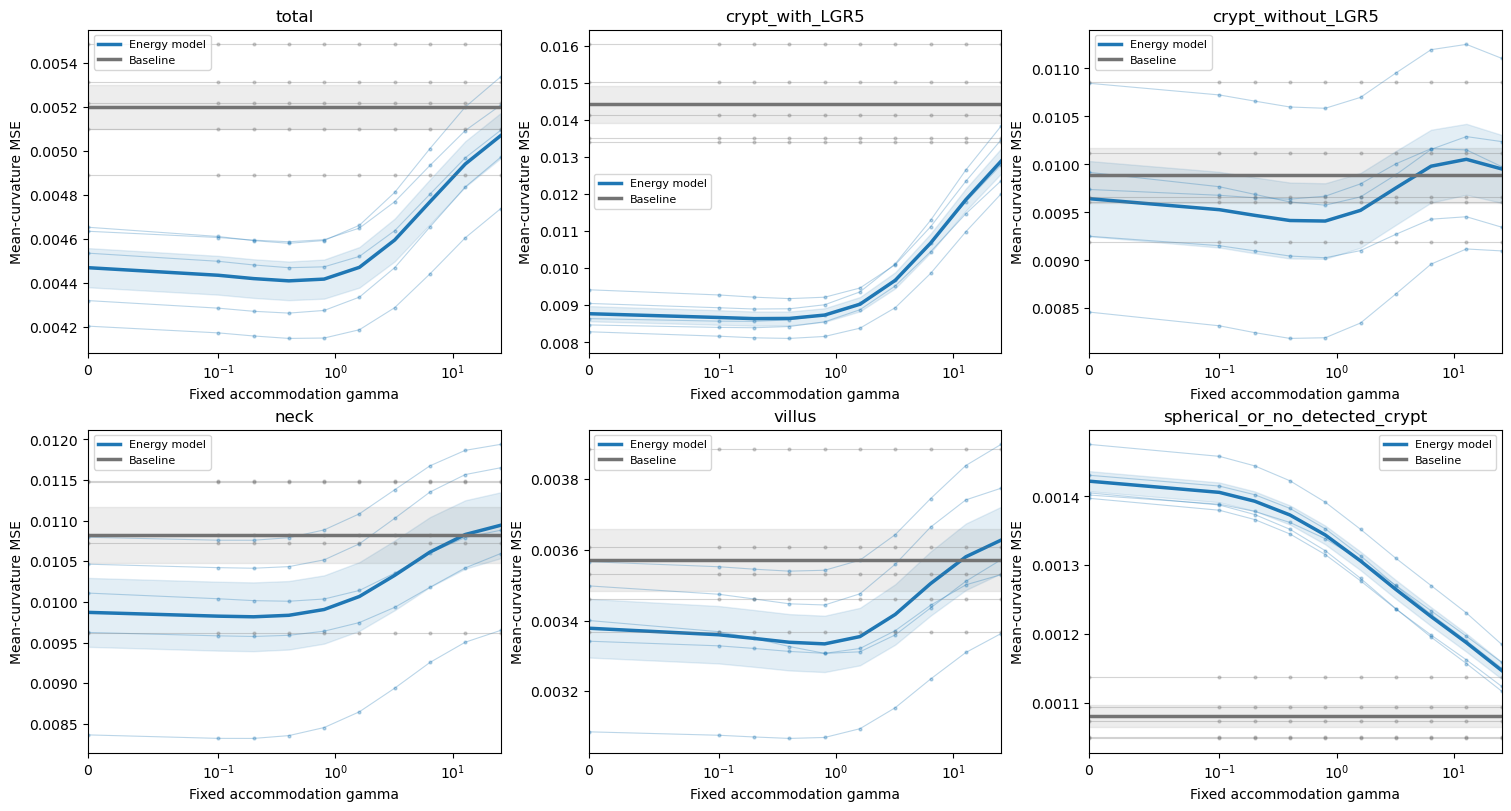

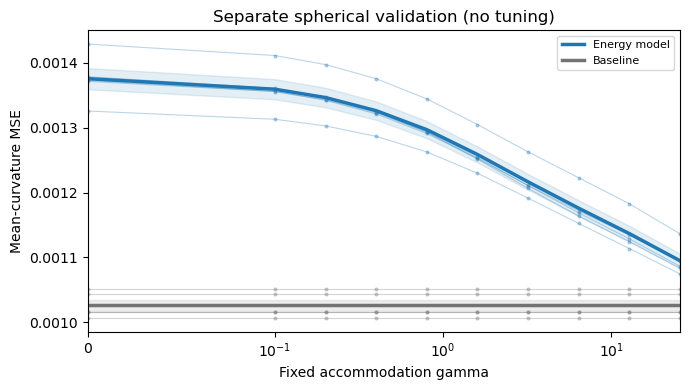

In [6]:
def plot_mse(ax,table,title):
    if table.empty:
        ax.text(.5,.5,'No eligible cells',ha='center',transform=ax.transAxes);ax.set_title(title);return
    gin_table=table[table.model=='gin']
    table=table[table.model=='energy']
    for column,label,color in [('mse','Energy model','tab:blue'),('baseline_mse','Baseline','0.45')]:
        fold_table=table.groupby(['fold','gamma'])[column].mean().reset_index()
        for fold,d in fold_table.groupby('fold'):ax.plot(d.gamma,d[column],color=color,alpha=FOLD_ALPHA,lw=THIN_LINE_WIDTH,marker='o',markersize=2)
        summary=fold_table.groupby('gamma')[column].agg(['mean','sem'])
        if table.fold.nunique()==1:summary['sem']=table.groupby('gamma')[column].sem()
        ax.plot(summary.index,summary['mean'],color=color,lw=MEAN_LINE_WIDTH,label=label)
        if SHOW_MSE_SEM:ax.fill_between(summary.index,summary['mean']-summary['sem'],summary['mean']+summary['sem'],color=color,alpha=.12)
    if len(gin_table):
        fm=gin_table.groupby('fold').mse.mean()
        for value in fm:ax.axhline(value,color='tab:green',alpha=FOLD_ALPHA,lw=THIN_LINE_WIDTH,marker='o',markersize=2)
        se=fm.sem() if len(fm)>1 else gin_table.mse.sem()
        ax.axhline(fm.mean(),color='tab:green',lw=MEAN_LINE_WIDTH,label='Plain depth-1 GIN')
        if SHOW_MSE_SEM:ax.axhspan(fm.mean()-se,fm.mean()+se,color='tab:green',alpha=.1)
    ax.set_xscale('symlog',linthresh=GAMMA_LINTHRESH)
    ax.set_xlim(min(settings['gamma_grid']),max(settings['gamma_grid']))
    ax.set(title=title,xlabel='Fixed accommodation gamma',ylabel='Mean-curvature MSE');ax.legend(fontsize=8)
labels=['total','crypt_with_LGR5','crypt_without_LGR5','neck','villus','spherical_or_no_detected_crypt']
fig,axes=plt.subplots(2,3,figsize=(15,8),layout='constrained')
for ax,label in zip(axes.flat,labels):plot_mse(ax,scores[scores.region==label],label)
fig.savefig(OUTPUT_DIR/'regional_mse_vs_gamma.png',dpi=160);plt.show()
fig,ax=plt.subplots(figsize=(7,4))
plot_mse(ax,scores[scores.region=='spherical_validation_only'],'Separate spherical validation (no tuning)')
fig.tight_layout();fig.savefig(OUTPUT_DIR/'spherical_mse_vs_gamma.png',dpi=160);plt.show()

## Center-identity preferred residual curvature
The coefficient \(a_A\) is the local preference when modeled direct source interactions are absent, relative to that fold's baseline. Incoming pairs follow the saved recipient/source panels. With all identities included as sources, zero source presence requires an isolated node: the preference is then an unsupported extrapolation unless such cells occur. Accommodation can still alter their final predicted curvature. These curves expose compensation as gamma changes; they are not measured isolated-cell curvatures. Thin lines are folds and thick lines their mean.

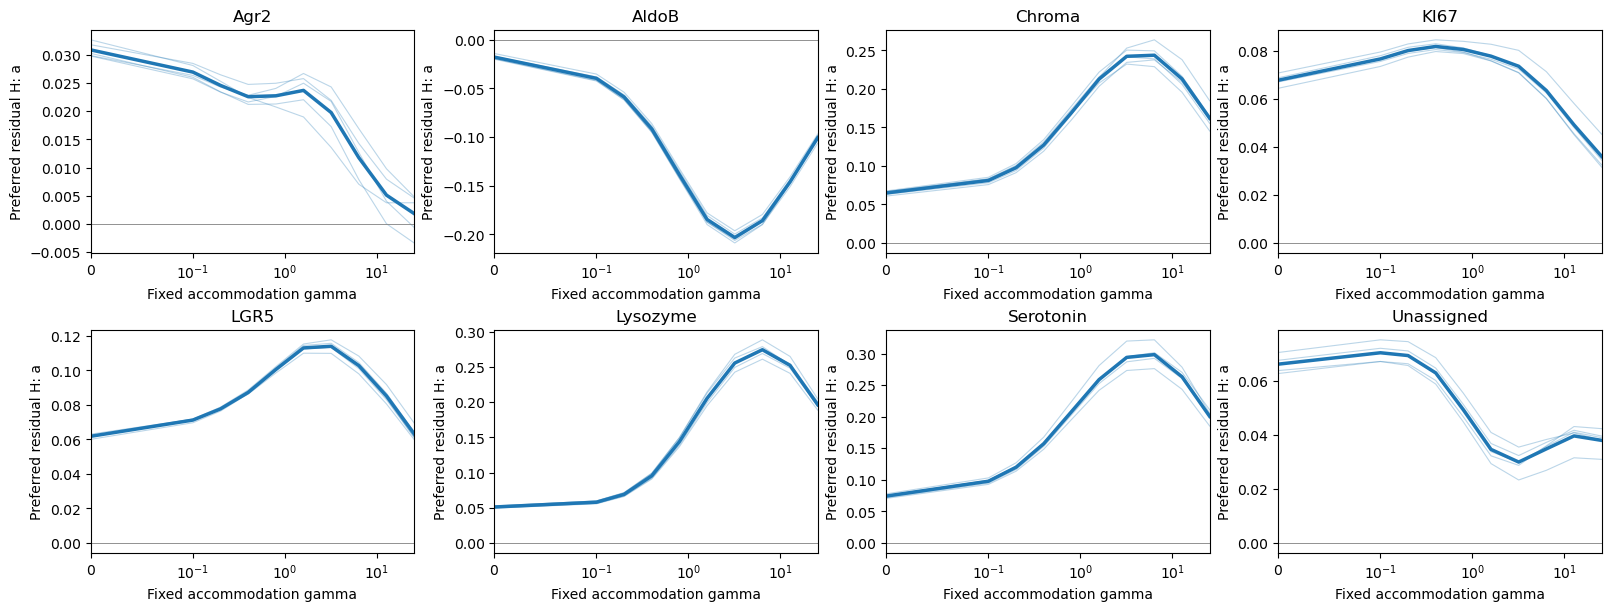

In [7]:
def plot_parameter(ax,table,title,color='tab:blue',label=None):
    for fold,d in table.groupby('fold'):
        d=d.sort_values('gamma');ax.plot(d.gamma,d.value,color=color,lw=THIN_LINE_WIDTH,alpha=FOLD_ALPHA)
    mean=table.groupby('gamma').value.mean().sort_index();ax.plot(mean.index,mean.values,color=color,lw=MEAN_LINE_WIDTH,label=label)
    ax.axhline(0,color='0.5',lw=.6);ax.set_xscale('symlog',linthresh=GAMMA_LINTHRESH)
    ax.set(title=title,xlabel='Fixed accommodation gamma',xlim=(min(settings['gamma_grid']),max(settings['gamma_grid'])))
columns=4;rows=int(np.ceil(len(identity_names)/columns))
fig,axes=plt.subplots(rows,columns,figsize=(4*columns,3*rows),squeeze=False,layout='constrained')
for ax,A in zip(axes.flat,identity_names):
    plot_parameter(ax,centers[centers.identity==A],A);ax.set_ylabel('Preferred residual H: a')
for ax in list(axes.flat)[len(identity_names):]:ax.set_visible(False)
fig.savefig(OUTPUT_DIR/'center_preferences_vs_gamma.png',dpi=160);plt.show()

## Source-to-recipient presence amplitudes
Each panel is one recipient identity; colored curves identify the source. Thin lines/small points show folds and thick lines the mean. A coefficient describes a change in local preferred residual curvature before accommodation as that source changes from absent to present. Self-identity pairs refer to a **different neighboring cell** of the same identity, never the center itself. Weakly supported and almost-always-present signals require caution. There is no reciprocity constraint on ordered pairs.

For linear interactions, beta multiplies the neighboring fraction (0–1). Fractions sum to one for nonempty neighborhoods, so raw center and amplitude values have a row-shift ambiguity. The extra diagnostics below assess variance, reference-relative effects, and prediction stability. Raw amplitude signs alone are not an identifiable linear-model property.

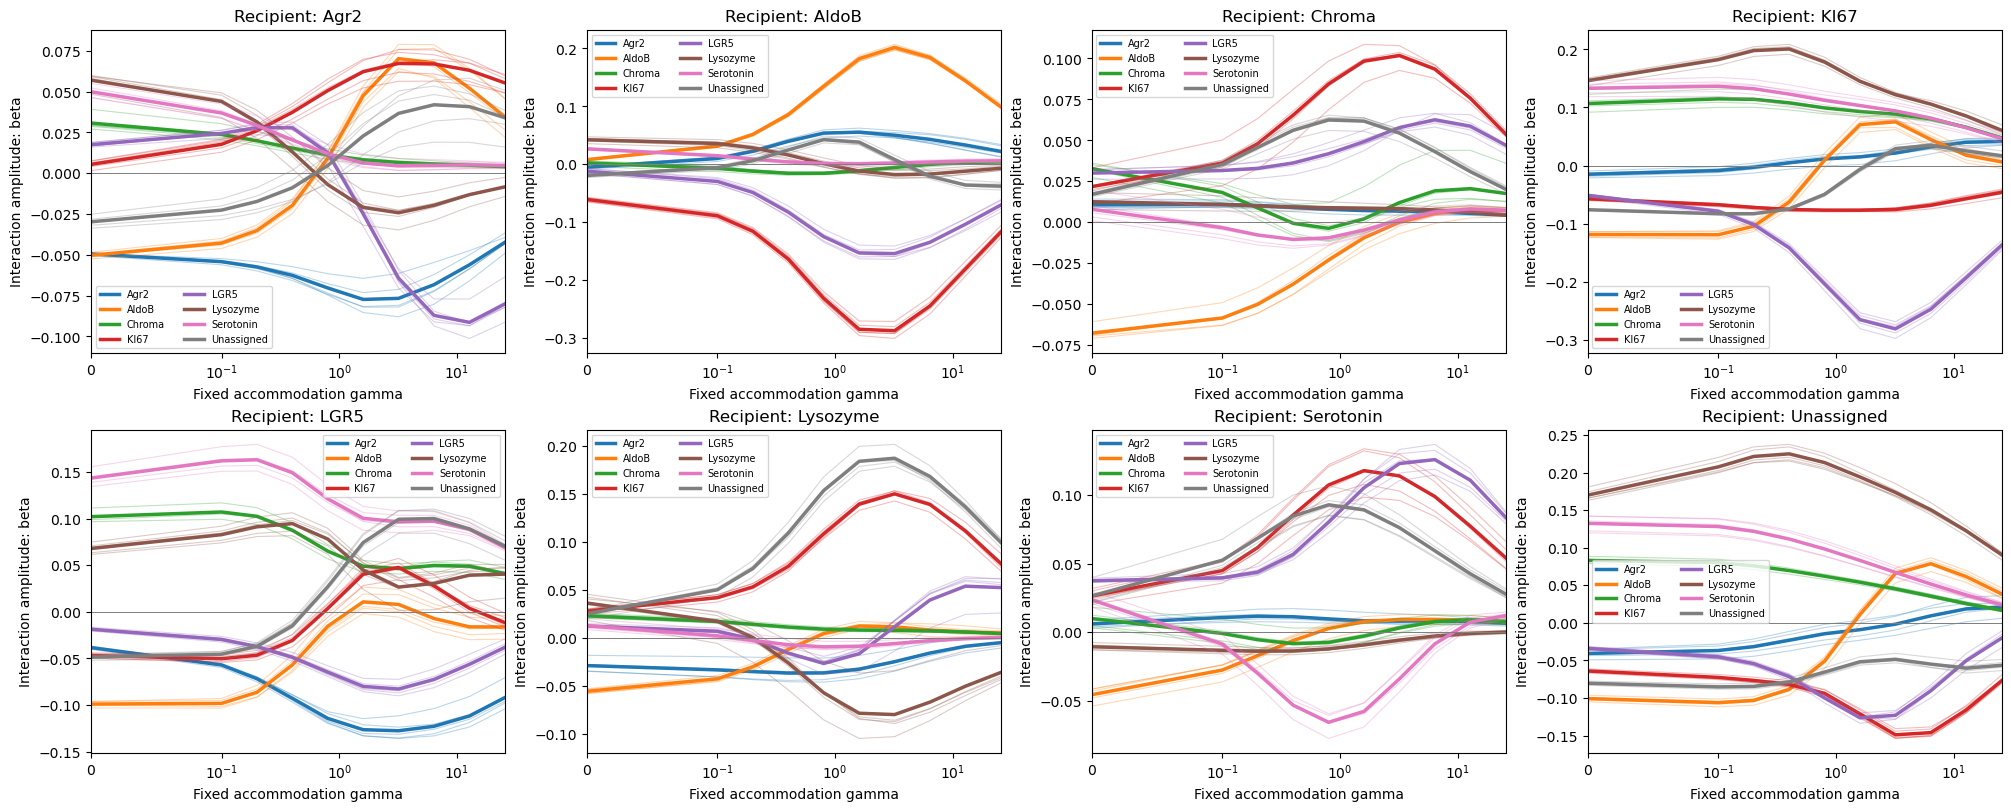

Saved figures, coefficients and held-out predictions: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/energy_model_training/all_to_all_linear_fraction_hop1_matched_20261002_133445/analysis/accommodation_profiles


In [8]:
recipient_names=settings['recipient_markers'];source_names=settings['source_markers']
columns=min(4,len(recipient_names));rows=int(np.ceil(len(recipient_names)/columns))
fig,axes=plt.subplots(rows,columns,figsize=(5*columns,4*rows),squeeze=False,layout='constrained')
source_colors={source:plt.get_cmap('tab10')(i) for i,source in enumerate(source_names)}
for ax,A in zip(axes.flat,recipient_names):
    for B in source_names:
        d=pairs[(pairs.recipient==A)&(pairs.source==B)]
        label=B+(' (low support)' if d.support.min()<settings['min_pair_organoids'] else '')
        plot_parameter(ax,d,f'Recipient: {A}',color=source_colors[B],label=label)
    ax.set_ylabel('Interaction amplitude: beta');ax.legend(fontsize=7,ncol=2)
for ax in list(axes.flat)[len(recipient_names):]:ax.set_visible(False)
fig.savefig(OUTPUT_DIR/'interaction_amplitudes_vs_gamma.png',dpi=160);plt.show()
print('Saved figures, coefficients and held-out predictions:',OUTPUT_DIR)


## Stability at each accommodation value
Measure cross-fold variation separately for every center preference and interaction amplitude. Show absolute SD, SD relative to coefficient RMS (with a near-zero floor), and signed agreement. A coefficient inside ±`SIGN_TOLERANCE` is counted as near zero, not as a reliable positive/negative sign. Zero signed agreement can mean a tie or all-near-zero folds; CSV tables retain these counts separately. This is descriptive robustness, not a significance test or evidence of mechanistic identification. Hatch interactions lacking presence **or absence** support. Each fold has its own baseline, so preferred residual curvature variation includes baseline uncertainty.

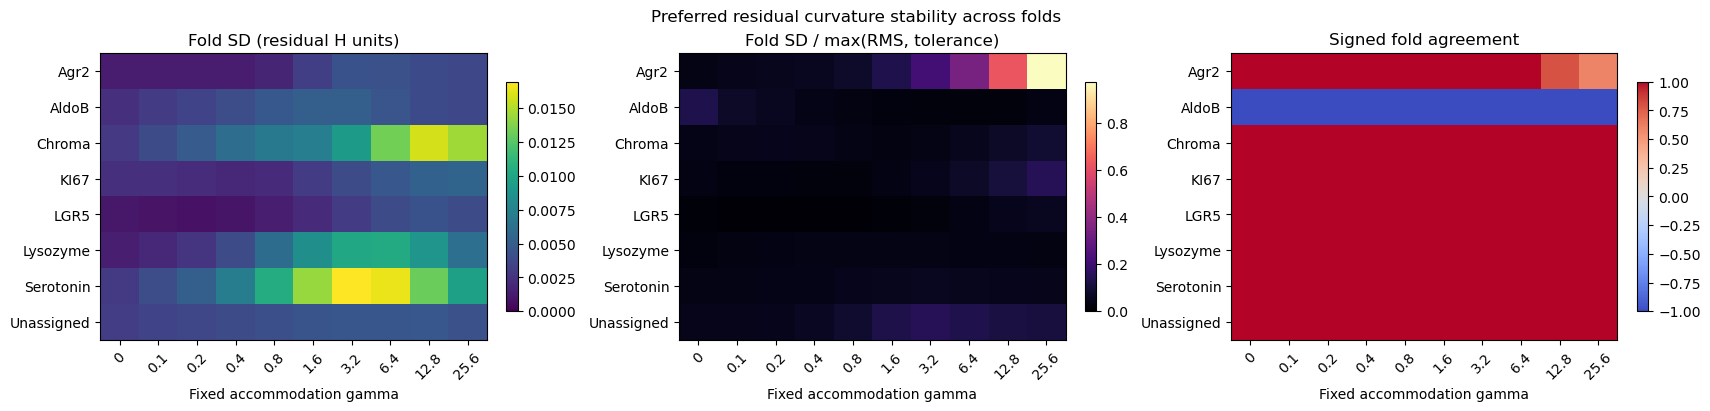

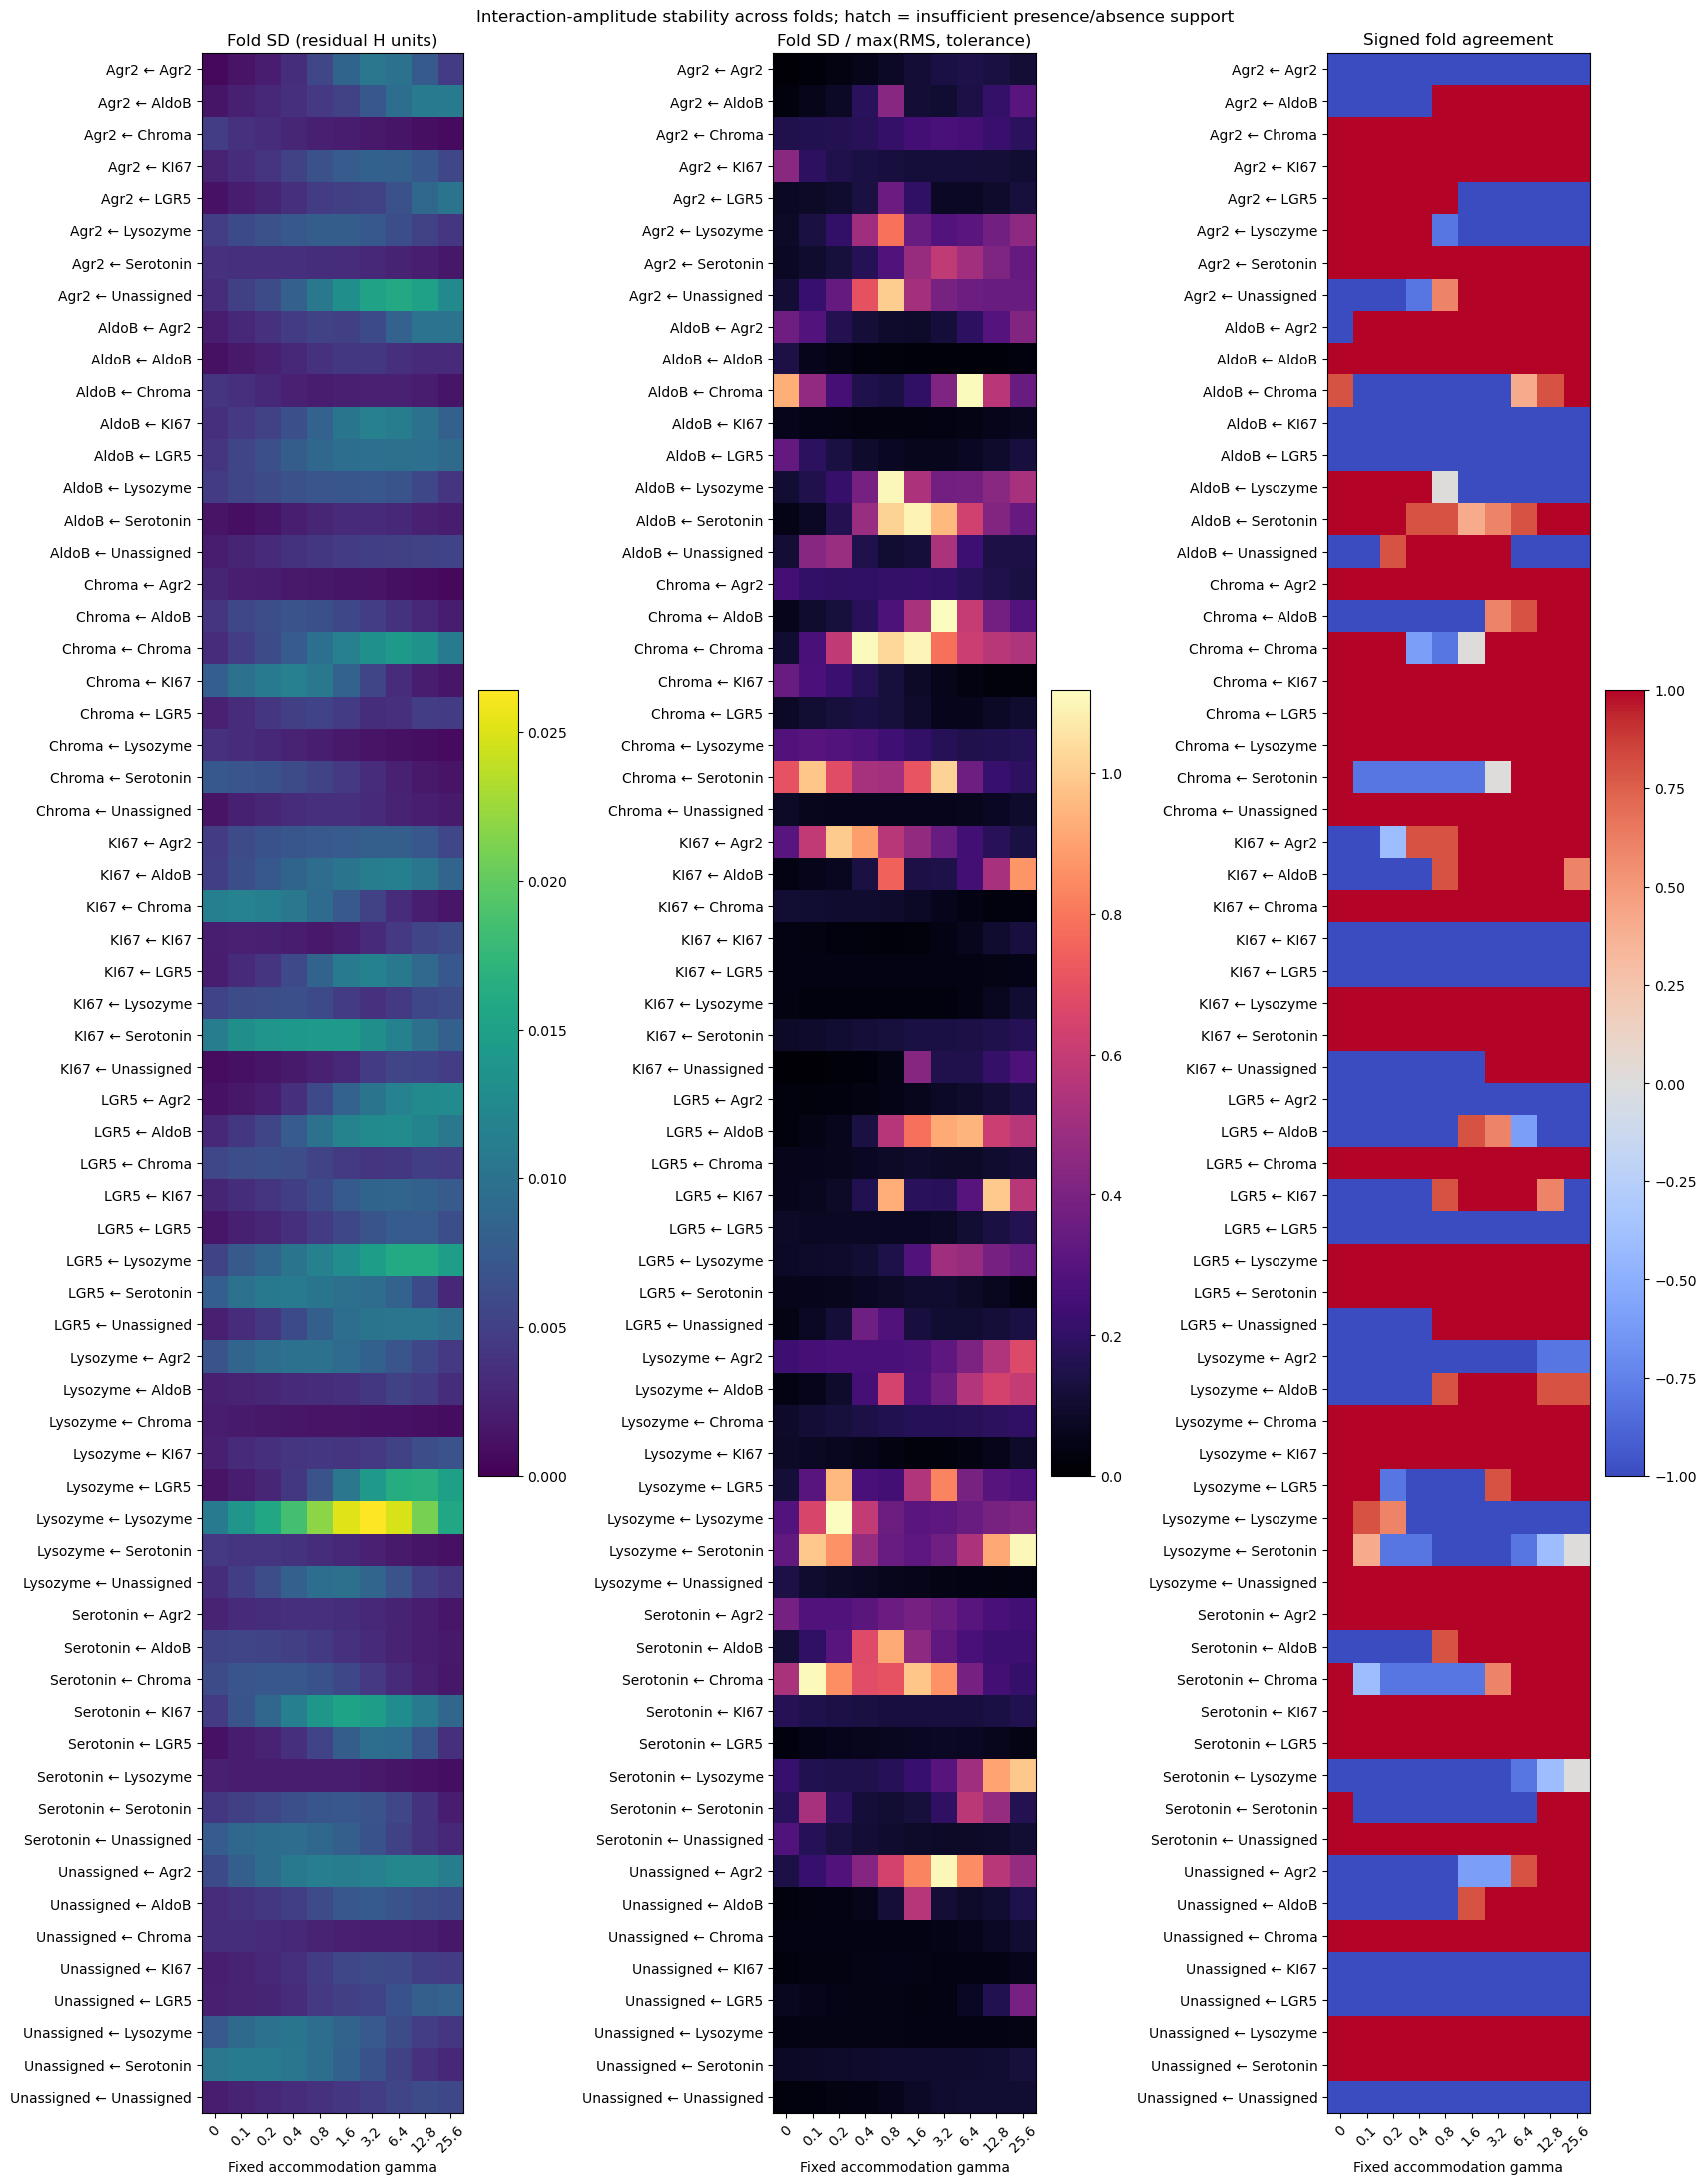

In [9]:
def summarize_stability(table,keys):
    rows=[]
    for key,group in table.groupby(['gamma',*keys],sort=False):
        values=group.value.to_numpy(float);n=len(values)
        if n!=len(membership) or group.fold.nunique()!=n:raise ValueError('Each parameter/gamma requires exactly one value per fold.')
        mean=values.mean();sd=values.std(ddof=1) if n>1 else np.nan;rms=np.sqrt(np.mean(values**2))
        positive=int((values>SIGN_TOLERANCE).sum());negative=int((values<-SIGN_TOLERANCE).sum());near_zero=n-positive-negative
        direction=1 if positive>negative else (-1 if negative>positive else 0)
        row=dict(zip(['gamma',*keys],key))
        row.update(mean=mean,sd=sd,minimum=values.min(),maximum=values.max(),rms=rms,
            relative_sd=sd/max(rms,SIGN_TOLERANCE),positive_folds=positive,negative_folds=negative,near_zero_folds=near_zero,
            signed_consensus=direction*max(positive,negative)/n,unanimous_nonzero_sign=positive==n or negative==n,
            all_near_zero=near_zero==n,raw_positive_folds=int((values>0).sum()),raw_negative_folds=int((values<0).sum()),folds=n)
        rows.append(row)
    return pd.DataFrame(rows)
center_stability=summarize_stability(centers,['identity'])
pair_stability=summarize_stability(pairs,['recipient','source'])
minimum_support=training_support.groupby(['recipient','source'])[['present_organoids','absent_organoids','source_free_organoids']].min().reset_index()
pair_stability=pair_stability.merge(minimum_support,on=['recipient','source'],validate='many_to_one')
pair_stability['adequate_support']=(pair_stability.present_organoids>=settings['min_pair_organoids'])&(pair_stability.absent_organoids>=settings['min_pair_organoids'])
for name,table in [('center_stability',center_stability),('interaction_stability',pair_stability)]:table.to_csv(OUTPUT_DIR/f'{name}.csv',index=False)

def plot_stability(table,labels,label_columns,title,filename):
    d=table.copy();d['label']=d[label_columns].agg(' ← '.join,axis=1)
    fig,axes=plt.subplots(1,3,figsize=(17,max(4,len(labels)*.34)),layout='constrained')
    for ax,quantity,cmap,bounds,label in zip(axes,['sd','relative_sd','signed_consensus'],['viridis','magma','coolwarm'],[(0,None),(0,None),(-1,1)],['Fold SD (residual H units)','Fold SD / max(RMS, tolerance)','Signed fold agreement']):
        matrix=d.pivot(index='label',columns='gamma',values=quantity).reindex(index=labels,columns=settings['gamma_grid'])
        im=ax.imshow(matrix,aspect='auto',cmap=cmap,vmin=bounds[0],vmax=bounds[1])
        ax.set(xticks=np.arange(len(settings['gamma_grid'])),xticklabels=[f'{g:g}' for g in settings['gamma_grid']],yticks=np.arange(len(labels)),yticklabels=labels,xlabel='Fixed accommodation gamma',title=label)
        ax.tick_params(axis='x',rotation=45);fig.colorbar(im,ax=ax,shrink=.8)
        if 'adequate_support' in d:
            support=d.pivot(index='label',columns='gamma',values='adequate_support').reindex(index=labels,columns=settings['gamma_grid'])
            for i,j in zip(*np.where(~support.to_numpy(bool))):ax.add_patch(Rectangle((j-.5,i-.5),1,1,fill=False,hatch='///',edgecolor='0.6',linewidth=0))
    fig.suptitle(title);fig.savefig(OUTPUT_DIR/filename,dpi=160);plt.show()
plot_stability(center_stability,identity_names,['identity'],'Preferred residual curvature stability across folds','center_fold_stability.png')
pair_labels=[f'{a} ← {b}' for a in settings['recipient_markers'] for b in settings['source_markers']]
plot_stability(pair_stability,pair_labels,['recipient','source'],'Interaction-amplitude stability across folds; hatch = insufficient presence/absence support','interaction_fold_stability.png')
stability_summary=[]
for family,table in [('center',center_stability),('interaction',pair_stability)]:
    for gamma,group in table.groupby('gamma'):
        usable=group if family=='center' else group[group.adequate_support]
        stability_summary.append(dict(family=family,gamma=gamma,parameters=len(group),supported_parameters=len(usable),
            unanimous_nonzero_sign=int(usable.unanimous_nonzero_sign.sum()),all_near_zero=int(usable.all_near_zero.sum()),
            median_sd=usable.sd.median(),median_relative_sd=usable.relative_sd.median()))
stability_summary=pd.DataFrame(stability_summary);stability_summary.to_csv(OUTPUT_DIR/'stability_summary.csv',index=False)


## Comparison with the saved reference model
Compare ordinary/spherical MSE and fold stability at identical gamma values using the same saved folds, targets and baseline models. Stability is compared separately for center preferences and the shared interaction pairs; panels or activation families may differ, so whole-table percentages alone would be misleading. Compare center stability conditionally: the preferred-curvature reference changes when the source panel changes. Fold agreement does not remove compensation or establish physical identifiability.

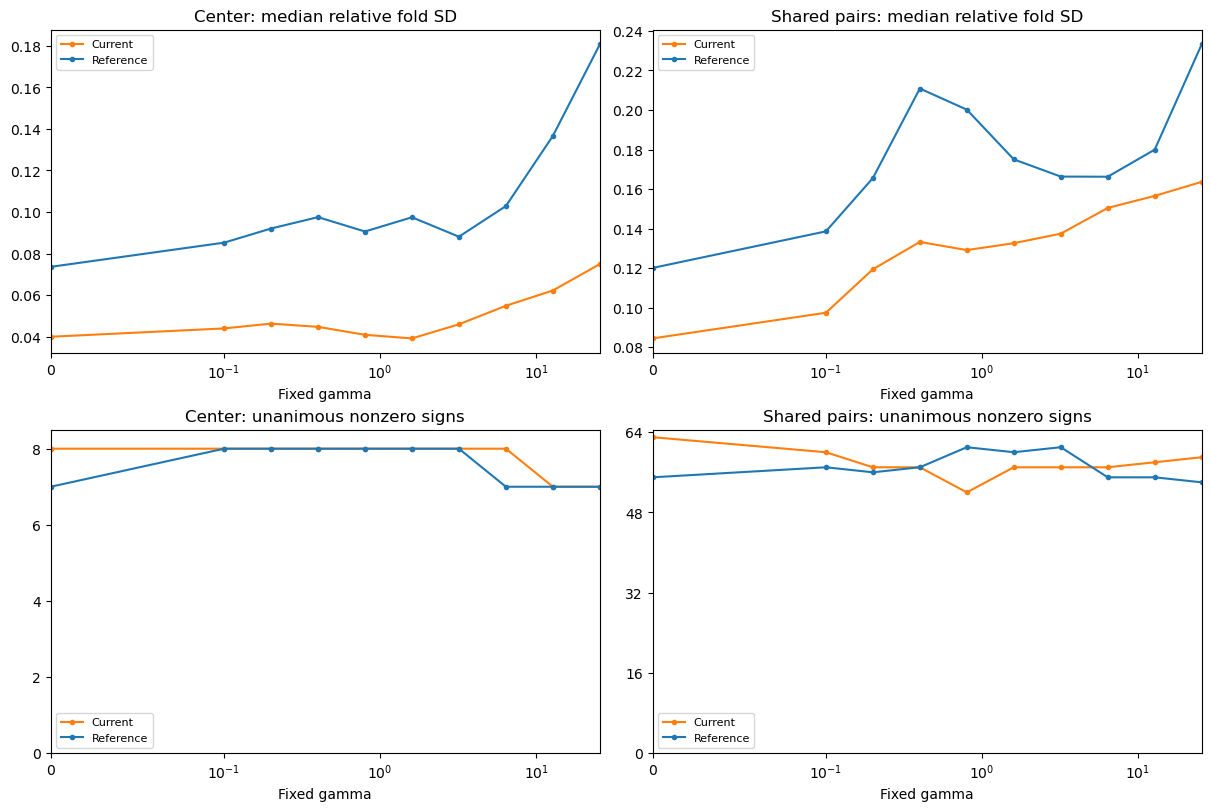

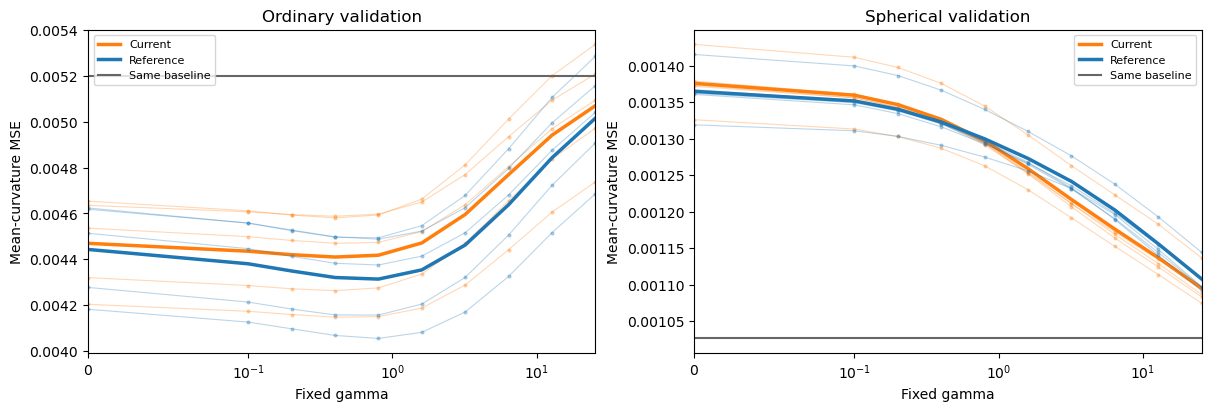

In [10]:
comparison_findings=[]
if STABILITY_REFERENCE_RUN is not None:
    reference_dir=resolve_training_run(PROJECT_ROOT,'energy_model_training',STABILITY_REFERENCE_RUN)
    reference_out=reference_dir/'analysis'/OUTPUT_TAG
    if membership!=json.loads((reference_dir/'splits.json').read_text()):raise ValueError('Stability comparison requires identical saved memberships.')
    reference_settings=json.loads((reference_dir/'settings.json').read_text())
    if settings['gamma_grid']!=reference_settings['gamma_grid']:raise ValueError('Comparison gamma grids differ.')
    for split in membership:
        relative=f"inputs/fold_{split['fold']}_mean/manifest.json"
        if json.loads((run.directory/relative).read_text())['files']!=json.loads((reference_dir/relative).read_text())['files']:raise ValueError('Comparison must use byte-identical prepared inputs/baselines.')
    ref_centers=pd.read_csv(reference_out/'center_preferences.csv')
    ref_pairs=pd.read_csv(reference_out/'interaction_amplitudes.csv')
    ref_center_stability=summarize_stability(ref_centers,['identity'])
    ref_pair_stability=summarize_stability(ref_pairs,['recipient','source'])
    ref_support=pd.read_csv(reference_out/'training_pair_presence_absence_support.csv').groupby(['recipient','source'])[['present_organoids','absent_organoids']].min().reset_index()
    ref_pair_stability=ref_pair_stability.merge(ref_support,on=['recipient','source'])
    ref_pair_stability['adequate_support']=(ref_pair_stability.present_organoids>=settings['min_pair_organoids'])&(ref_pair_stability.absent_organoids>=settings['min_pair_organoids'])
    common=pair_stability.merge(ref_pair_stability,on=['gamma','recipient','source'],suffixes=('_current','_reference'),validate='one_to_one')
    common['joint_support']=common.adequate_support_current&common.adequate_support_reference
    common.to_csv(OUTPUT_DIR/'common_interaction_stability.csv',index=False)
    center_comparison=center_stability.merge(ref_center_stability,on=['gamma','identity'],suffixes=('_current','_reference'),validate='one_to_one')
    center_comparison.to_csv(OUTPUT_DIR/'center_stability_comparison.csv',index=False)
    comparison_rows=[]
    for gamma in settings['gamma_grid']:
        for label,cs,ps in [('Current',center_stability,pair_stability),('Reference',ref_center_stability,ref_pair_stability)]:
            c=cs[cs.gamma==gamma];p=ps[ps.gamma==gamma]
            common_keys=common[(common.gamma==gamma)&common.joint_support][['recipient','source']]
            p=p.merge(common_keys,on=['recipient','source'])
            comparison_rows.append(dict(model=label,gamma=gamma,center_median_relative_sd=c.relative_sd.median(),center_unanimous=int(c.unanimous_nonzero_sign.sum()),
                common_pair_median_relative_sd=p.relative_sd.median(),common_pair_unanimous=int(p.unanimous_nonzero_sign.sum()),common_pairs=len(p)))
    stability_comparison=pd.DataFrame(comparison_rows);stability_comparison.to_csv(OUTPUT_DIR/'stability_comparison.csv',index=False)
    fig,axes=plt.subplots(2,2,figsize=(12,8),layout='constrained')
    for label,color in [('Current','tab:orange'),('Reference','tab:blue')]:
        d=stability_comparison[stability_comparison.model==label]
        for ax,column,title in zip(axes.flat,['center_median_relative_sd','common_pair_median_relative_sd','center_unanimous','common_pair_unanimous'],['Center: median relative fold SD','Shared pairs: median relative fold SD','Center: unanimous nonzero signs','Shared pairs: unanimous nonzero signs']):
            ax.plot(d.gamma,d[column],'-o',color=color,label=label,markersize=3)
            ax.set_xscale('symlog',linthresh=GAMMA_LINTHRESH);ax.set_xlim(min(settings['gamma_grid']),max(settings['gamma_grid']));ax.set(title=title,xlabel='Fixed gamma');ax.legend(fontsize=8)
    axes[1,0].set(ylim=(0,len(identity_names)+.5),yticks=np.arange(0,len(identity_names)+1,2))
    pair_count=int(stability_comparison.common_pairs.max())
    axes[1,1].set(ylim=(0,pair_count+.5),yticks=np.arange(0,pair_count+1,max(1,pair_count//4)))
    fig.savefig(OUTPUT_DIR/'reference_stability_comparison.png',dpi=160);plt.show()
    current_scores=pd.read_csv(run.directory/'validation_mse.csv');reference_scores=pd.read_csv(reference_dir/'validation_mse.csv')
    joined=current_scores.merge(reference_scores,on=['fold','gamma','cohort','organoid_str'],suffixes=('_current','_reference'),validate='one_to_one')
    if len(joined)!=len(current_scores) or len(joined)!=len(reference_scores) or not np.allclose(joined.baseline_mse_current,joined.baseline_mse_reference,rtol=0,atol=0):raise ValueError('MSE comparison has mismatched support or baselines.')
    joined['mse_difference']=joined.mse_current-joined.mse_reference
    joined.to_csv(OUTPUT_DIR/'paired_reference_mse.csv',index=False)
    fold_diff=joined.groupby(['cohort','gamma','fold']).mse_difference.mean().reset_index()
    fold_diff.groupby(['cohort','gamma']).mse_difference.agg(['mean','std','sem']).to_csv(OUTPUT_DIR/'paired_reference_mse_summary.csv')
    fig,axes=plt.subplots(1,2,figsize=(12,4),layout='constrained')
    for ax,role in zip(axes,['val','spherical']):
        for frame,label,color in [(current_scores,'Current','tab:orange'),(reference_scores,'Reference','tab:blue')]:
            fold_table=frame[frame.cohort==role].groupby(['fold','gamma']).mse.mean().reset_index()
            for fold,d in fold_table.groupby('fold'):ax.plot(d.gamma,d.mse,color=color,alpha=FOLD_ALPHA,lw=THIN_LINE_WIDTH,marker='o',markersize=2)
            mean=fold_table.groupby('gamma').mse.mean();ax.plot(mean.index,mean.values,color=color,lw=MEAN_LINE_WIDTH,label=label)
        baseline_mean=reference_scores[(reference_scores.gamma==settings['gamma_grid'][0])&(reference_scores.cohort==role)].groupby('fold').baseline_mse.mean().mean()
        ax.axhline(baseline_mean,color='0.4',label='Same baseline')
        ax.set_xscale('symlog',linthresh=GAMMA_LINTHRESH);ax.set_xlim(min(settings['gamma_grid']),max(settings['gamma_grid']));ax.set(title='Ordinary validation' if role=='val' else 'Spherical validation',xlabel='Fixed gamma',ylabel='Mean-curvature MSE');ax.legend(fontsize=8)
    fig.savefig(OUTPUT_DIR/'reference_mse_comparison.png',dpi=160);plt.show()
    comparison_findings=['## Matched interaction-model reference','',f'Reference: `{reference_dir.name}`. Fold inputs and baseline bundles are byte-identical. Compare like-for-like at each gamma; pair-stability comparisons use only the shared, jointly supported pairs. Different panels/activation families change coefficient interpretations. Raw variance ratios must be read with reference-relative effects and prediction stability, not as stand-alone biological reliability.','',
        'See `reference_mse_comparison.png`, `reference_stability_comparison.png`, and their paired CSV tables in `analysis/accommodation_profiles/`.']


## Variance, reference-invariant effects and prediction reliability
Compare **sample variance across folds**, not only SD, at every matched gamma. Report both the ratio of total coefficient variance and the median of individual variance ratios, alongside relative SD and sign agreement. Larger linear coefficients can reflect different exposure scaling; raw variance ratios alone are insufficient.

For linear all-to-all fractions on non-isolated cells, `a_A → a_A − delta_A` and every `beta_AB → beta_AB + delta_A` preserve the local preferred curvature exactly. The unchanged ridge penalties select a numerical split; they do not make it physically identifiable. Analyze `a_A + beta_AU` and `beta_AB − beta_AU`, with U = the selected reference identity, as invariant summaries. For both families these describe pure-neighborhood endpoint values/contrasts, which may not have observational support. No reference is asserted to have zero biological contribution. Finally compare predictions on identical spherical organoids held out from every fold.

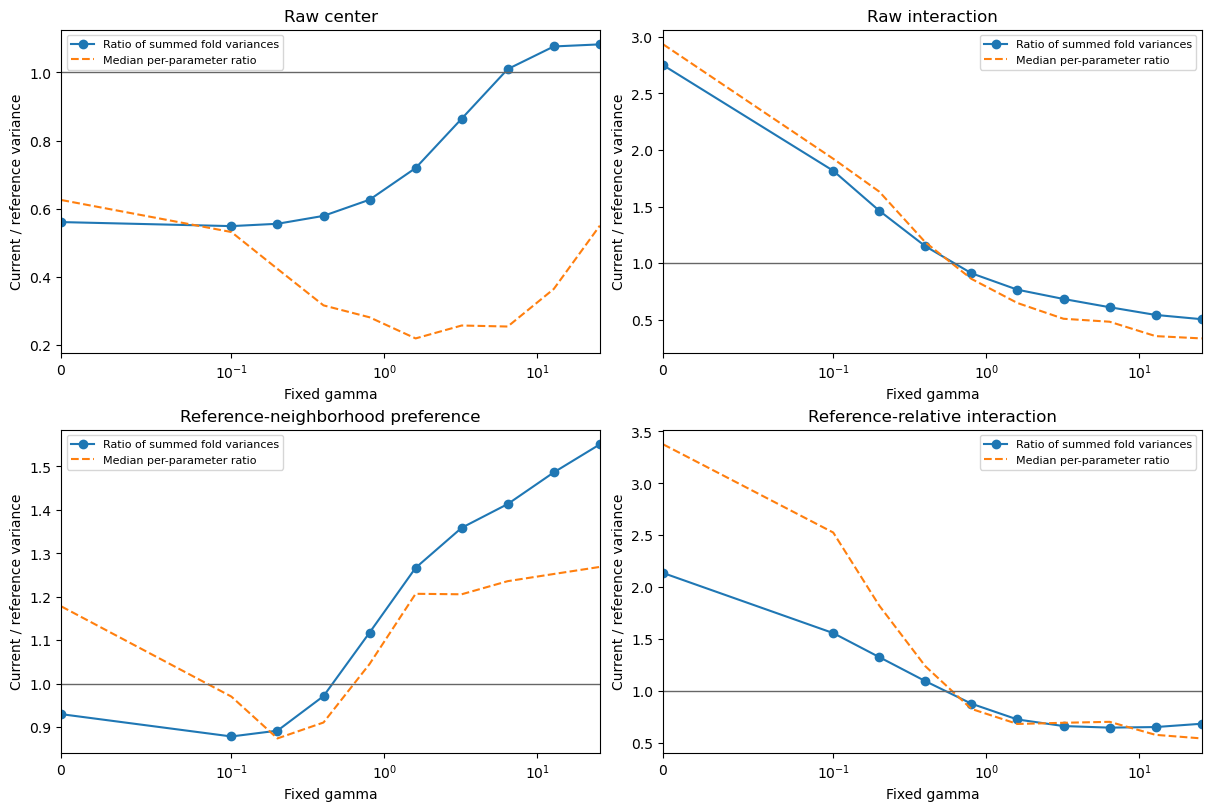

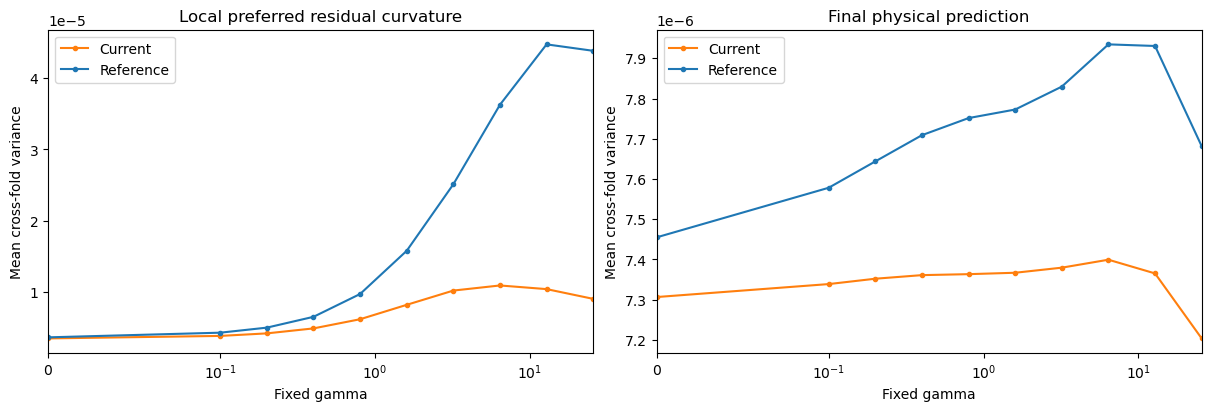

In [11]:
variance_summary=pd.DataFrame();contrast_variance=pd.DataFrame();response_variance=pd.DataFrame();design_diagnostics=pd.DataFrame()
if STABILITY_REFERENCE_RUN is not None and set(settings['source_markers'])==set(identity_names) and set(settings['recipient_markers'])==set(identity_names) and set(reference_settings['source_markers'])==set(identity_names) and set(reference_settings['recipient_markers'])==set(identity_names):
    def compare_variances(left,right,keys,family):
        joined=left.merge(right,on=['gamma',*keys],suffixes=('_current','_reference'),validate='one_to_one')
        joined['variance_current']=joined.sd_current**2;joined['variance_reference']=joined.sd_reference**2
        joined['variance_ratio']=np.divide(joined.variance_current,joined.variance_reference,out=np.full(len(joined),np.nan),where=joined.variance_reference>VARIANCE_FLOOR)
        joined['family']=family
        return joined
    def reference_relative(center_table,pair_table):
        reference=pair_table[pair_table.source==COEFFICIENT_REFERENCE][['fold','gamma','recipient','value']].rename(columns={'value':'reference_value'})
        effects=pair_table.merge(reference,on=['fold','gamma','recipient'],validate='many_to_one')
        effects['value']=effects.value-effects.reference_value
        effects=effects[effects.source!=COEFFICIENT_REFERENCE].copy()
        anchors=center_table.merge(reference.rename(columns={'recipient':'identity'}),on=['fold','gamma','identity'],validate='one_to_one')
        anchors['value']=anchors.value+anchors.reference_value
        return summarize_stability(anchors,['identity']),summarize_stability(effects,['recipient','source'])
    relative_centers,relative_pairs=reference_relative(centers,pairs)
    ref_relative_centers,ref_relative_pairs=reference_relative(ref_centers,ref_pairs)
    variance_tables=[compare_variances(center_stability,ref_center_stability,['identity'],'Raw center'),compare_variances(pair_stability,ref_pair_stability,['recipient','source'],'Raw interaction'),
        compare_variances(relative_centers,ref_relative_centers,['identity'],'Reference-neighborhood preference'),compare_variances(relative_pairs,ref_relative_pairs,['recipient','source'],'Reference-relative interaction')]
    for frame in variance_tables:
        frame.to_csv(OUTPUT_DIR/(frame.family.iloc[0].lower().replace(' ','_')+'_variance_comparison.csv'),index=False)
    rows=[]
    for frame in variance_tables:
        for gamma,d in frame.groupby('gamma'):
            rows.append(dict(family=d.family.iloc[0],gamma=gamma,parameters=len(d),mean_variance_current=d.variance_current.mean(),mean_variance_reference=d.variance_reference.mean(),
                aggregate_variance_ratio=d.variance_current.sum()/d.variance_reference.sum() if d.variance_reference.sum()>VARIANCE_FLOOR else np.nan,
                median_parameter_variance_ratio=d.variance_ratio.median(),ratios_defined=int(d.variance_ratio.notna().sum()),
                median_relative_sd_current=d.relative_sd_current.median(),median_relative_sd_reference=d.relative_sd_reference.median(),
                unanimous_current=int(d.unanimous_nonzero_sign_current.sum()),unanimous_reference=int(d.unanimous_nonzero_sign_reference.sum())))
    variance_summary=pd.DataFrame(rows);variance_summary.to_csv(OUTPUT_DIR/'parameter_variance_summary.csv',index=False)
    fig,axes=plt.subplots(2,2,figsize=(12,8),layout='constrained')
    for ax,(family,d) in zip(axes.flat,variance_summary.groupby('family',sort=False)):
        ax.plot(d.gamma,d.aggregate_variance_ratio,'-o',label='Ratio of summed fold variances')
        ax.plot(d.gamma,d.median_parameter_variance_ratio,'--',label='Median per-parameter ratio')
        ax.axhline(1,color='0.4',lw=1);ax.set_xscale('symlog',linthresh=GAMMA_LINTHRESH);ax.set_xlim(min(settings['gamma_grid']),max(settings['gamma_grid']))
        ax.set(title=family,xlabel='Fixed gamma',ylabel='Current / reference variance');ax.legend(fontsize=8)
    fig.savefig(OUTPUT_DIR/'parameter_variance_ratios.png',dpi=160);plt.show()

    # Rank of the unpenalized local design. Accommodation is invertible and cannot restore lost rank.
    diagnostic_rows=[];t=len(identity_names)
    for split in membership:
        gram={name:np.zeros((t+t*t,t+t*t)) for name in ['linear','presence']};max_null=0.;isolated=0
        for oid in split['train']:
            ids,counts=raw_context[oid];population=counts.sum(1,keepdims=True)
            fractions=np.divide(counts,population,out=np.zeros_like(counts,dtype=float),where=population>0)
            isolated+=int((population[:,0]==0).sum());onehot=np.eye(t)[ids]
            for name,values in [('linear',fractions),('presence',(counts>0).astype(float))]:
                x=np.c_[onehot,(onehot[:,:,None]*values[:,None,:]).reshape(len(ids),-1)]
                gram[name]+=x.T@x/(len(split['train'])*len(ids))
                if name=='linear':
                    # Shift a_A by -delta_A and every beta_AB by +delta_A: local prediction changes by zero.
                    delta=np.linspace(.01,.08,t)
                    max_null=max(max_null,float(np.max(np.abs(-delta[ids]+delta[ids]*fractions.sum(1)))))
        for name,g in gram.items():
            eigenvalues=np.linalg.eigvalsh(g);rank=int((eigenvalues>max(eigenvalues.max(),1.)*1e-10).sum())
            diagnostic_rows.append(dict(fold=split['fold'],activation=name,columns=len(g),rank=rank,nullity=len(g)-rank,isolated_cells=isolated,
                row_shift_max_local_change=max_null if name=='linear' else np.nan))
    design_diagnostics=pd.DataFrame(diagnostic_rows);design_diagnostics.to_csv(OUTPUT_DIR/'unpenalized_design_diagnostics.csv',index=False)

    # Common unseen contexts: the spherical cohort is excluded from training in every fold.
    spherical_ids=membership[0]['spherical_validation']
    if spherical_ids:
        if any(split['spherical_validation']!=spherical_ids for split in membership):raise ValueError('Common-context prediction stability requires identical external memberships.')
        ids=np.concatenate([raw_context[oid][0] for oid in spherical_ids]);counts=np.concatenate([raw_context[oid][1] for oid in spherical_ids]);population=counts.sum(1,keepdims=True)
        fractions=np.divide(counts,population,out=np.zeros_like(counts,dtype=float),where=population>0)
        offsets=np.r_[0,np.cumsum([len(raw_context[oid][0]) for oid in spherical_ids])]
        response_rows=[]
        for name,directory,record_table,c_table,p_table,activation in [('Current',run.directory,energy_records,centers,pairs,settings['activation']),('Reference',reference_dir,pd.read_json(reference_dir/'models.json'),ref_centers,ref_pairs,reference_settings['activation'])]:
            exposures=fractions if activation=='linear' else (counts>0).astype(float)
            for gamma in settings['gamma_grid']:
                local=[];predicted=[]
                for split in membership:
                    f=split['fold'];a=c_table[(c_table.fold==f)&(c_table.gamma==gamma)].set_index('identity').value.reindex(identity_names).to_numpy()
                    beta=p_table[(p_table.fold==f)&(p_table.gamma==gamma)].pivot(index='recipient',columns='source',values='value').reindex(index=identity_names,columns=identity_names).to_numpy()
                    local.append(a[ids]+np.sum(beta[ids]*exposures,axis=1))
                    record=record_table[(record_table.fold==f)&(record_table.gamma==gamma)&(record_table.family=='energy')].iloc[0]
                    with np.load(directory/'analysis'/OUTPUT_TAG/'predictions'/f'{record.key}_spherical.npz',allow_pickle=False) as archive:
                        if not np.array_equal(archive['organoid_ids'],spherical_ids) or not np.array_equal(archive['offsets'],offsets):raise ValueError('Common-context predictions are not aligned.')
                        predicted.append(archive['prediction'].copy())
                for quantity,values in [('Local preferred residual curvature',local),('Final physical prediction',predicted)]:
                    node_variance=np.var(np.asarray(values),axis=0,ddof=1)
                    for i,oid in enumerate(spherical_ids):response_rows.append(dict(model=name,gamma=gamma,quantity=quantity,organoid_str=oid,mean_node_variance=float(node_variance[offsets[i]:offsets[i+1]].mean())))
        response_variance=pd.DataFrame(response_rows);response_variance.to_csv(OUTPUT_DIR/'common_context_response_variance.csv',index=False)
        response_summary=response_variance.groupby(['model','gamma','quantity']).mean_node_variance.mean().reset_index()
        response_summary.to_csv(OUTPUT_DIR/'common_context_variance_summary.csv',index=False)
        fig,axes=plt.subplots(1,2,figsize=(12,4),layout='constrained')
        for ax,quantity in zip(axes,['Local preferred residual curvature','Final physical prediction']):
            for label,color in [('Current','tab:orange'),('Reference','tab:blue')]:
                d=response_summary[(response_summary.quantity==quantity)&(response_summary.model==label)]
                ax.plot(d.gamma,d.mean_node_variance,'-o',label=label,color=color,markersize=3)
            ax.set_xscale('symlog',linthresh=GAMMA_LINTHRESH);ax.set_xlim(min(settings['gamma_grid']),max(settings['gamma_grid']));ax.set(title=quantity,xlabel='Fixed gamma',ylabel='Mean cross-fold variance');ax.legend()
        fig.savefig(OUTPUT_DIR/'common_context_prediction_stability.png',dpi=160);plt.show()


## Summary and saved report
Summarize fold-mean validation performance, coefficient stability and composition definitions in a report beside the checkpoints. The minimum of the ordinary-validation curve is descriptive; spherical organoids never select accommodation. Repeated spherical evaluations are summarized across folds, not counted as independent organoids.

In [12]:
# Aggregate within each fold first: spherical organoids are reused across models, not new independent observations.
fold_scores=scores.groupby(['model','gamma','fold','region'],dropna=False).agg(mse=('mse','mean'),baseline_mse=('baseline_mse','mean'),organoids=('organoid_str','nunique')).reset_index()
fold_scores.to_csv(OUTPUT_DIR/'fold_validation_mse.csv',index=False)
summary=fold_scores.groupby(['model','gamma','region'],dropna=False).mse.agg(['mean','std','sem','count']).reset_index().rename(columns={'count':'folds'})
summary.to_csv(OUTPUT_DIR/'comparison_summary.csv',index=False)
curve=summary[(summary.model=='energy')&(summary.region=='total')].set_index('gamma')['mean']
best_gamma=float(curve.idxmin())
selected=scores[(scores.model=='gin')|((scores.model=='energy')&(scores.gamma==best_gamma))].copy()
baseline=selected[selected.model=='energy'].copy();baseline['model']='baseline';baseline['mse']=baseline.baseline_mse
comparison=pd.concat([selected,baseline],ignore_index=True)
fold_comparison=comparison.groupby(['region','model','fold']).mse.mean().reset_index()
comparison_summary=fold_comparison.groupby(['region','model']).mse.agg(['mean','std','sem','count']).reset_index().rename(columns={'count':'folds'})
comparison_summary.to_csv(OUTPUT_DIR/'selected_gamma_comparison.csv',index=False)
paired=[]
for region,group in comparison.groupby('region'):
    wide=group.pivot(index=['fold','organoid_str'],columns='model',values='mse')
    for first,second in [('energy','baseline'),('gin','baseline'),('energy','gin')]:
        if first not in wide or second not in wide:continue
        difference=(wide[first]-wide[second]).dropna();fold_difference=difference.groupby('fold').mean()
        paired.append(dict(region=region,contrast=f'{first} - {second}',mean_difference=float(fold_difference.mean()),fold_sem=float(fold_difference.sem()),folds=len(fold_difference),unique_organoids=difference.index.get_level_values('organoid_str').nunique()))
pd.DataFrame(paired).to_csv(OUTPUT_DIR/'paired_mse_differences.csv',index=False)
def markdown_table(frame):
    out=['| '+' | '.join(map(str,frame.columns))+' |','| '+' | '.join(['---']*len(frame.columns))+' |']
    for row in frame.itertuples(index=False,name=None):out.append('| '+' | '.join(f'{v:.6g}' if isinstance(v,float) else str(v) for v in row)+' |')
    return '\n'.join(out)
cohort_counts=cohort_table.cohort.value_counts()
lines=['# Folded fixed-accommodation energy analysis','',f'Run: `{run.directory.name}`. {len(membership)} folds, {cohort_counts.get("ordinary",0)} ordinary organoids, {cohort_counts.get("spherical",0)} separate spherical-validation organoids.','',
    '## Design','',f'Activation: {settings["activation"]}; reference activation: {reference_settings["activation"] if STABILITY_REFERENCE_RUN is not None else "none"}.','',
    'Mean curvature, exclusive fates, one-hop neighbor interactions. Source and recipient panels are recorded explicitly in settings; overlapping panels permit all-to-all interactions. Every identity retains its own preferred residual curvature. Baselines and preprocessing are fitted separately within ordinary training folds; pair shrinkage is selected on an inner training holdout. No local N-dependence, learned saturation or measured-neighbor targets were added. No GIN is trained when gin_enabled=False.','',
    'The same spherical cohort is evaluated in every fold and never fits or selects anything. Fold curves are descriptive: their training sets overlap, and repeated spherical predictions are not independent observations. Preferred residual coefficients are relative to each fold\'s own fitted global baseline; fold variation includes baseline uncertainty.','',
    '## Accommodation and validation MSE','',markdown_table(summary[(summary.model=='energy')&(summary.region=='total')][['gamma','mean','std','sem','folds']]),'',
    f'The smallest fold-mean ordinary-validation MSE is at gamma={best_gamma:g}. This is a descriptive minimum on this validation sweep, not a separately tested selection or an independently measured mechanical constant.','',
    markdown_table(comparison_summary),'',
    'MSE is averaged over organoids within each fold, then equally over folds. SEM is across fold means; overlapping training membership prevents an independent-replicate interpretation. Regional means have different support and should not be averaged to reconstruct total MSE.','',
    '## Coefficient stability','',f'Sources: {settings["source_markers"]}. Recipients: {settings["recipient_markers"]}. There are {len(identity_names)} center preferences and {len(settings["source_markers"])*len(settings["recipient_markers"])} pair amplitudes per gamma.','',
    f'Near-zero tolerance: {SIGN_TOLERANCE:g} in preferred residual mean-curvature units (a descriptive choice, not a significance test). Signed agreement is the majority positive/negative fold fraction, with that sign; near-zero folds count toward neither sign. Zero can mean a sign tie or entirely near-zero values, so consult the accompanying counts. Relative dispersion is sample fold SD divided by max(fold RMS, tolerance).','',
    markdown_table(stability_summary),'',
    f'Interaction support requires at least {settings["min_pair_organoids"]} training organoids with presence and at least that many with absence in every fold. Hatching flags inadequate support; support alone does not rule out confounding among sources. Full per-parameter tables include raw sign counts, near-zero counts, ranges, SD, and support. Stable signs do not identify absolute signaling strengths.','',
    '## Cohort and source-neighborhood composition','',
    'Composition uses every eligible original organoid once, without duplication across folds. Each organoid has equal weight. One-hop neighborhoods exclude the source center and count unique adjacent cells; average neighbor fractions over source centers within each organoid, then over organoids containing a non-isolated source. Source-absent organoids are excluded from that conditional panel, not entered as zero. Error bars are organoid SEM, not fold uncertainty.','',
    'EXO combines Agr2 and Lysozyme; ENDO combines Chroma and Serotonin. Other identities remain separate. This is a descriptive grouping of exclusive marker labels, not evidence of tracked differentiation. Cohorts are not matched for N or timepoint; their composition contrasts may reflect these differences.','',
    '## Figures','',
    '- `analysis/accommodation_profiles/cohort_composition.png`: spherical-like versus non-spherical identity and lineage composition.',
    '- `analysis/accommodation_profiles/source_neighborhood_composition.png`: one-hop composition around the selected source identities.',
    '- `analysis/accommodation_profiles/regional_mse_vs_gamma.png`: thin fold curves and thick fold means, alongside each fold\'s baseline.',
    '- `analysis/accommodation_profiles/spherical_mse_vs_gamma.png`: separate spherical validation.',
    '- `analysis/accommodation_profiles/center_preferences_vs_gamma.png`: all center preferences, fold curves and means.',
    '- `analysis/accommodation_profiles/interaction_amplitudes_vs_gamma.png`: all source-to-recipient coefficients, fold curves and means.',
    '- `analysis/accommodation_profiles/center_fold_stability.png`: preference SD, relative dispersion and signed fold agreement at every gamma.',
    '- `analysis/accommodation_profiles/interaction_fold_stability.png`: analogous interaction stability, with support flags.','',
    'All checkpoints, baseline models, exact memberships, fitted transformations, scores, predictions, compositions and stability tables are saved with the run.']
means=comparison_summary.set_index(['region','model'])['mean']
fold_minima=fold_scores[(fold_scores.model=='energy')&(fold_scores.region=='total')].sort_values('mse').groupby('fold').first().gamma
stable=stability_summary[stability_summary.gamma==best_gamma].set_index('family')
findings=['## Main findings','',
    f"Ordinary validation: energy MSE {means['total','energy']:.7f} versus baseline {means['total','baseline']:.7f} at gamma={best_gamma:g}. {int((fold_minima==best_gamma).sum())}/{len(fold_minima)} folds have their minimum at this gamma.", '',
    f"At that gamma, {int(stable.loc['interaction','unanimous_nonzero_sign'])}/{int(stable.loc['interaction','supported_parameters'])} supported interactions have unanimous nonzero signs; their median relative fold dispersion is {100*stable.loc['interaction','median_relative_sd']:.1f}%. Center preferences: {int(stable.loc['center','unanimous_nonzero_sign'])}/{int(stable.loc['center','parameters'])} unanimous nonzero signs, median relative dispersion {100*stable.loc['center','median_relative_sd']:.1f}%.", '',
    'Agreement at a fixed gamma does not remove the systematic coefficient changes across gamma. Treat stable signs as conditional associations; preferred curvature and accommodation are still not independently identified.', '']
if 'spherical_validation_only' in set(summary.region):
    spherical_curve=summary[(summary.model=='energy')&(summary.region=='spherical_validation_only')].set_index('gamma')['mean']
    findings += [f"Separate spherical validation: energy MSE {means['spherical_validation_only','energy']:.7f} at gamma={best_gamma:g}; at the largest gamma={max(settings['gamma_grid']):g}, MSE is {spherical_curve.loc[max(settings['gamma_grid'])]:.7f}. Baseline MSE is {means['spherical_validation_only','baseline']:.7f}. The cohort was not used to select parameters.", '']
composition_means=composition_lineages.groupby(['identity','cohort']).fraction.mean().unstack('cohort')
if {'ordinary','spherical'}<=set(composition_means.columns):
    findings+=['Whole-organoid lineage composition (mean fraction per organoid):','',markdown_table(composition_means.reset_index()),'']
    neighbor_means=neighborhood_lineages[neighborhood_lineages.identity=='LGR5'].groupby(['source','cohort']).fraction.mean().unstack('cohort')
    findings+=['LGR5 fraction among the immediate neighbors of each source (conditional on a usable source being present):','',markdown_table(neighbor_means.reset_index()),'',
        'These source-containing neighborhoods can remain LGR5-rich even when source identities are less prevalent across the spherical cohort. A simple absence-of-sources explanation is therefore insufficient on its own. The cohort comparison is descriptive and unmatched for N/timepoint.', '']
source_free=training_support.groupby('recipient').source_free_organoids.agg(['min','max']).reset_index()
findings+=['Source-free training support (organoids per fold):','',markdown_table(source_free),'']
if source_free['max'].eq(0).all():
    findings+=['No recipient identity has a source-free training context in any fold. Center preferences are extrapolated zero-exposure intercepts. Their fold agreement is not evidence for an isolated-cell preferred curvature; regularization and compensation with interaction terms can support reproducible intercepts without that interpretation.', '']
if STABILITY_REFERENCE_RUN is not None:
    ref_curve=reference_scores[reference_scores.cohort=='val'].groupby(['fold','gamma']).mse.mean().groupby('gamma').mean()
    comparison_gammas=sorted({best_gamma,float(ref_curve.idxmin())})
    compact=stability_comparison[stability_comparison.gamma.isin(comparison_gammas)].copy()
    for index,row in compact.iterrows():
        source=current_scores if row.model=='Current' else reference_scores
        for role,column in [('val','ordinary_mse'),('spherical','spherical_mse')]:
            compact.loc[index,column]=source[(source.gamma==row.gamma)&(source.cohort==role)].groupby('fold').mse.mean().mean()
    compact.to_csv(OUTPUT_DIR/'compact_reference_comparison.csv',index=False)
    findings+=['Matched comparison at the current and reference validation minima (both models evaluated at each gamma):','',markdown_table(compact),'',
        'For stability, compare the same pairs at the same gamma. When source/recipient panels differ, distinguish shared-pair comparisons from the full interaction table. Similar fixed-gamma stability does not establish improved mechanical identification or reduced accommodation/preference compensation.', '']
if len(variance_summary):
    selected_variance=variance_summary[variance_summary.gamma.isin(comparison_gammas)]
    compact_variance=selected_variance[['family','gamma','parameters','aggregate_variance_ratio']].copy()
    compact_variance['variance_change_percent']=100*(compact_variance.pop('aggregate_variance_ratio')-1)
    findings+=['## Parameter variance and reliability','',markdown_table(compact_variance),'',
        'Ratios compare sample fold variances at identical gamma. Summed-variance ratios and median per-parameter ratios are both reported; they need not coincide. Fold samples overlap and these are descriptive, not independent variance estimates. Raw beta has different exposure scaling for fraction and presence responses, so a larger raw variance alone is not evidence of poorer predictive reliability. The same numerical ridge penalties also act differently after changing input scaling.', '',
        f'Reference-neighborhood preference is a_A + beta_A,{COEFFICIENT_REFERENCE}. Reference-relative interaction is beta_AB - beta_A,{COEFFICIENT_REFERENCE}. These describe pure-neighborhood endpoint contrasts for both response families; for the linear model they are invariant to its exact center/row-amplitude ambiguity. Such pure neighborhoods may be outside observed support, and this is not a causal replacement experiment.', '',
        markdown_table(design_diagnostics),'',
        'For a linear all-to-all model, u_i = a_A + sum_B beta_AB x_iB and sum_B x_iB = 1. Therefore a_A -> a_A - delta_A together with beta_AB -> beta_AB + delta_A for every B leaves u_i unchanged. There is one such ambiguity per recipient identity. Linear row shifts preserve predictions on non-isolated cells. A positive ridge gives a unique numerical fit but does not identify those separate physical parameters. The rank check omits ridge; invertible accommodation cannot restore a missing design direction.', '',
        'See parameter_variance_ratios.png and common_context_prediction_stability.png. Common-context prediction variance uses only the shared spherical cohort, unseen by all folds, with equal organoid weighting. Its physical predictions include baseline variation. Stability on this cohort does not imply accuracy or remove cohort-shift bias.', '']
if len(variance_summary) and settings['activation']=='linear' and reference_settings['activation']=='presence':
    selected_response=response_summary[response_summary.gamma.isin(comparison_gammas)].pivot(index=['gamma','quantity'],columns='model',values='mean_node_variance').reset_index()
    selected_response['variance_change_percent']=100*(selected_response.Current/selected_response.Reference-1)
    findings+=['### Reliability conclusion','']
    for gamma in comparison_gammas:
        d=selected_variance[selected_variance.gamma==gamma].set_index('family')
        changes=100*(d.aggregate_variance_ratio-1)
        findings += [f"At gamma={gamma:g}, average raw center variance changes by {changes['Raw center']:+.1f}%, raw interaction variance by {changes['Raw interaction']:+.1f}%, and reference-relative interaction variance by {changes['Reference-relative interaction']:+.1f}%. These percentages concern variance, not standard deviation. Reference-relative interaction signs agree in all folds for {int(d.loc['Reference-relative interaction','unanimous_current'])}/{int(d.loc['Reference-relative interaction','parameters'])} current contrasts and {int(d.loc['Reference-relative interaction','unanimous_reference'])}/{int(d.loc['Reference-relative interaction','parameters'])} reference contrasts.", '']
    findings+=[markdown_table(selected_response),'',
        'These common-context variances measure stability across folds on the same unseen spherical organoids. Stability must be considered separately from their validation MSE. Fold sign agreement is descriptive and conditional on the chosen reference and gamma.', '',
        'The linear model can be used for predictive associations and appropriately supported reference-relative effects. Its separate absolute center preferences and raw interaction amplitudes are not physically identifiable because of the exact row-shift ambiguity above. Ridge resolves the numerical optimization, not this interpretation. Presence having full rank also does not establish causal or mechanical identification. Low fold variance alone is insufficient to interpret either model as independently measured physical parameters.', '']
lines[2:2]=findings
lines+=['',*comparison_findings,'']
display(Markdown('\n'.join(findings)))
(run.directory/'REPORT.md').write_text('\n'.join(lines)+'\n')
(OUTPUT_DIR/'complete.json').write_text(json.dumps(dict(models=len(run.records),folds=len(membership),gamma_grid=settings['gamma_grid'],sphere_used_for_selection=False,composition_organoids=len(cohort_table),stability_sign_tolerance=SIGN_TOLERANCE),indent=2))
print('Report:',run.directory/'REPORT.md')
display(comparison_summary[comparison_summary.region.isin(['total','spherical_validation_only'])])


## Main findings

Ordinary validation: energy MSE 0.0044092 versus baseline 0.0052015 at gamma=0.4. 5/5 folds have their minimum at this gamma.

At that gamma, 57/64 supported interactions have unanimous nonzero signs; their median relative fold dispersion is 13.3%. Center preferences: 8/8 unanimous nonzero signs, median relative dispersion 4.5%.

Agreement at a fixed gamma does not remove the systematic coefficient changes across gamma. Treat stable signs as conditional associations; preferred curvature and accommodation are still not independently identified.

Separate spherical validation: energy MSE 0.0013263 at gamma=0.4; at the largest gamma=25.6, MSE is 0.0010949. Baseline MSE is 0.0010262. The cohort was not used to select parameters.

Whole-organoid lineage composition (mean fraction per organoid):

| identity | ordinary | spherical |
| --- | --- | --- |
| AldoB | 0.398905 | 0.721011 |
| ENDO | 0.00758285 | 0.00339639 |
| EXO | 0.0567716 | 0.0345015 |
| KI67 | 0.175374 | 0.0586661 |
| LGR5 | 0.131992 | 0.0674595 |
| Unassigned | 0.229374 | 0.114966 |

LGR5 fraction among the immediate neighbors of each source (conditional on a usable source being present):

| source | ordinary | spherical |
| --- | --- | --- |
| Agr2 | 0.233695 | 0.21253 |
| AldoB | 0.0168111 | 0.0117916 |
| Chroma | 0.431751 | 0.410533 |
| KI67 | 0.0840002 | 0.0815011 |
| LGR5 | 0.546384 | 0.588276 |
| Lysozyme | 0.451865 | 0.432548 |
| Serotonin | 0.514681 | 0.517435 |
| Unassigned | 0.0506627 | 0.0378583 |

These source-containing neighborhoods can remain LGR5-rich even when source identities are less prevalent across the spherical cohort. A simple absence-of-sources explanation is therefore insufficient on its own. The cohort comparison is descriptive and unmatched for N/timepoint.

Source-free training support (organoids per fold):

| recipient | min | max |
| --- | --- | --- |
| Agr2 | 0 | 0 |
| AldoB | 0 | 0 |
| Chroma | 0 | 0 |
| KI67 | 0 | 0 |
| LGR5 | 0 | 0 |
| Lysozyme | 0 | 0 |
| Serotonin | 0 | 0 |
| Unassigned | 0 | 0 |

No recipient identity has a source-free training context in any fold. Center preferences are extrapolated zero-exposure intercepts. Their fold agreement is not evidence for an isolated-cell preferred curvature; regularization and compensation with interaction terms can support reproducible intercepts without that interpretation.

Matched comparison at the current and reference validation minima (both models evaluated at each gamma):

| model | gamma | center_median_relative_sd | center_unanimous | common_pair_median_relative_sd | common_pair_unanimous | common_pairs | ordinary_mse | spherical_mse |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Current | 0.4 | 0.0447816 | 8 | 0.133258 | 57 | 64 | 0.00440917 | 0.0013263 |
| Reference | 0.4 | 0.0975586 | 8 | 0.210857 | 57 | 64 | 0.00431983 | 0.00132263 |
| Current | 0.8 | 0.0409511 | 8 | 0.129146 | 52 | 64 | 0.00441716 | 0.00129698 |
| Reference | 0.8 | 0.090647 | 8 | 0.200164 | 61 | 64 | 0.00431291 | 0.0012996 |

For stability, compare the same pairs at the same gamma. When source/recipient panels differ, distinguish shared-pair comparisons from the full interaction table. Similar fixed-gamma stability does not establish improved mechanical identification or reduced accommodation/preference compensation.

## Parameter variance and reliability

| family | gamma | parameters | variance_change_percent |
| --- | --- | --- | --- |
| Raw center | 0.4 | 8 | -42.1316 |
| Raw center | 0.8 | 8 | -37.3841 |
| Raw interaction | 0.4 | 64 | 14.959 |
| Raw interaction | 0.8 | 64 | -8.91686 |
| Reference-neighborhood preference | 0.4 | 8 | -2.86993 |
| Reference-neighborhood preference | 0.8 | 8 | 11.7509 |
| Reference-relative interaction | 0.4 | 56 | 9.61701 |
| Reference-relative interaction | 0.8 | 56 | -12.0809 |

Ratios compare sample fold variances at identical gamma. Summed-variance ratios and median per-parameter ratios are both reported; they need not coincide. Fold samples overlap and these are descriptive, not independent variance estimates. Raw beta has different exposure scaling for fraction and presence responses, so a larger raw variance alone is not evidence of poorer predictive reliability. The same numerical ridge penalties also act differently after changing input scaling.

Reference-neighborhood preference is a_A + beta_A,Unassigned. Reference-relative interaction is beta_AB - beta_A,Unassigned. These describe pure-neighborhood endpoint contrasts for both response families; for the linear model they are invariant to its exact center/row-amplitude ambiguity. Such pure neighborhoods may be outside observed support, and this is not a causal replacement experiment.

| fold | activation | columns | rank | nullity | isolated_cells | row_shift_max_local_change |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | linear | 72 | 64 | 8 | 0 | 1.38778e-17 |
| 0 | presence | 72 | 72 | 0 | 0 | nan |
| 1 | linear | 72 | 64 | 8 | 0 | 1.38778e-17 |
| 1 | presence | 72 | 72 | 0 | 0 | nan |
| 2 | linear | 72 | 64 | 8 | 0 | 1.38778e-17 |
| 2 | presence | 72 | 72 | 0 | 0 | nan |
| 3 | linear | 72 | 64 | 8 | 0 | 1.38778e-17 |
| 3 | presence | 72 | 72 | 0 | 0 | nan |
| 4 | linear | 72 | 64 | 8 | 0 | 1.38778e-17 |
| 4 | presence | 72 | 72 | 0 | 0 | nan |

For a linear all-to-all model, u_i = a_A + sum_B beta_AB x_iB and sum_B x_iB = 1. Therefore a_A -> a_A - delta_A together with beta_AB -> beta_AB + delta_A for every B leaves u_i unchanged. There is one such ambiguity per recipient identity. Linear row shifts preserve predictions on non-isolated cells. A positive ridge gives a unique numerical fit but does not identify those separate physical parameters. The rank check omits ridge; invertible accommodation cannot restore a missing design direction.

See parameter_variance_ratios.png and common_context_prediction_stability.png. Common-context prediction variance uses only the shared spherical cohort, unseen by all folds, with equal organoid weighting. Its physical predictions include baseline variation. Stability on this cohort does not imply accuracy or remove cohort-shift bias.

### Reliability conclusion

At gamma=0.4, average raw center variance changes by -42.1%, raw interaction variance by +15.0%, and reference-relative interaction variance by +9.6%. These percentages concern variance, not standard deviation. Reference-relative interaction signs agree in all folds for 49/56 current contrasts and 45/56 reference contrasts.

At gamma=0.8, average raw center variance changes by -37.4%, raw interaction variance by -8.9%, and reference-relative interaction variance by -12.1%. These percentages concern variance, not standard deviation. Reference-relative interaction signs agree in all folds for 49/56 current contrasts and 41/56 reference contrasts.

| gamma | quantity | Current | Reference | variance_change_percent |
| --- | --- | --- | --- | --- |
| 0.4 | Final physical prediction | 7.36103e-06 | 7.70889e-06 | -4.5124 |
| 0.4 | Local preferred residual curvature | 4.83515e-06 | 6.46173e-06 | -25.1725 |
| 0.8 | Final physical prediction | 7.36344e-06 | 7.75141e-06 | -5.00524 |
| 0.8 | Local preferred residual curvature | 6.12379e-06 | 9.66966e-06 | -36.6701 |

These common-context variances measure stability across folds on the same unseen spherical organoids. Stability must be considered separately from their validation MSE. Fold sign agreement is descriptive and conditional on the chosen reference and gamma.

The linear model can be used for predictive associations and appropriately supported reference-relative effects. Its separate absolute center preferences and raw interaction amplitudes are not physically identifiable because of the exact row-shift ambiguity above. Ridge resolves the numerical optimization, not this interpretation. Presence having full rank also does not establish causal or mechanical identification. Low fold variance alone is insufficient to interpret either model as independently measured physical parameters.


Report: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/energy_model_training/all_to_all_linear_fraction_hop1_matched_20261002_133445/REPORT.md


,region,model,mean,std,sem,folds
8,spherical_validation_only,baseline,0.001026,0.000020,0.000009,5
9,spherical_validation_only,energy,0.001326,0.000032,0.000014,5
10,total,baseline,0.005202,0.000224,0.000100,5
11,total,energy,0.004409,0.000197,0.000088,5
